









lista 





feedback


envio formulario
correo


In [ ]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

## lista seguimiento

In [ ]:
# ruta_archivo = os.path.join(ruta_csv, 'ALFIN BANCO SEGUIMIENTO 0807.csv')
# df_seguimiento=cargar_archivo_csv(spark,ruta_archivo,';',True)
# print(df_seguimiento.columns)

# query = """
#     select NUMERO_DOCUMENTO as DNI,*
#     from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
#     """
# df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
# print(df_formato.columns)

['DNI', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'RETIRO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RAN

In [3]:


# df_seguimiento = df_seguimiento.withColumn(
#     "DNI",
#     F.date_format(
#         F.to_date(F.col("DNI"), "d/MM/yyyy"),
#         "yyyy-MM-dd"
#     )
# )
df_seguimiento = df_seguimiento.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)
df_seguimiento=df_seguimiento.join(df_formato,['DNI'],'left')

df_seguimiento=df_seguimiento.withColumn('CLIENTE',when(F.col('CLIENTE').isNull(),F.col('NOMBRES')).otherwise(F.col('CLIENTE')))
df_seguimiento=df_seguimiento.withColumnRenamed('DNI','vendor_lead_code')
df_seguimiento=df_seguimiento.withColumnRenamed('CLIENTE','address1')
df_seguimiento=df_seguimiento.withColumnRenamed('TELEFONO','phone_number')
df_seguimiento=df_seguimiento.withColumnRenamed('PLAZA','email')
df_seguimiento=df_seguimiento.withColumnRenamed('MONTO','comments')
df_seguimiento=df_seguimiento.select('vendor_lead_code','address1','phone_number','email','comments')

df_list_filtrada = df_seguimiento.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_seguimiento.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)


NameError: name 'df_seguimiento' is not defined

### lista gestion

In [5]:
query = """
    select *
    from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
    where (cl_telf1 is not null and cl_telf1<>0) 
    and cl_base='julio 2026'
    and lote!='Bot'
    and OFERTA_MAX>=5000
    and NUMERO_DOCUMENTO not in(
    '09676119','71412698'
    )
    and cl_telf1 not in(
    '931788073','922310602'
    )
    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [10]:
df_formato.select('lote').distinct().show()

+--------------+
|          lote|
+--------------+
|           BOT|
|    NO CLIENTE|
|NO CLIENTE CET|
+--------------+



In [ ]:
['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'RETIRO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'SERVICIO', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'marca1', 'marca2', 'marca3', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE', 'FLAT2', 'REP1', 'REP2']ofer

['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'RETIRO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUEL

In [12]:
# grupo_tasa=['None', '', '', '', '', ]
# agencia_comercial=[ 'SAN MIGUEL', 'MIRAFLORES']

df_filtrado = df_formato.filter(
    # (F.col('propension_ic').isin('1','2','3'))&
    # (F.col('proveedor').isin(['INVENTARIO TARGET 2', 'CET TARGET 2', 'CET TARGET 0', 'INVENTARIO TARGET 1', 'INVENTARIO TARGET 0', ]))&
    # (F.col('user_v3').isin(user_v3))&

    # (
    # (F.col('TIPO_CLIENTE').isin('INDEPENDIENT','INFORMAL'))&
    (F.col('propension_ic').isin('2'))&
    (F.col('OFERTA_MAX').between(7000,15000))&
    (F.col('frescura').isin('1','4'))&
    # )
    (F.col('USER_V3').isin('7. Peers'))
)


print(df_filtrado.count())
print(df_filtrado.columns)

4668
['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'RETIRO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO

## lista BOT

In [ ]:
df_lista=df_lista.withColumnRenamed('COD_AGENCIA','AGENCIA')

df_lista=df_lista.withColumnRenamed('DNI','VENDOR LEAD CODE')
df_lista=df_lista.withColumnRenamed('CELULAR','PHONE NUMBER')
df_lista=df_lista.withColumnRenamed('NOMBRE','ADDRESS1')
df_lista=df_lista.withColumnRenamed('Agencia','TIENDA_CERCANA_LIMPIA')
df_lista=df_lista.withColumnRenamed('Monto de oferta','OFERTA_MAX_TEXTO')

df_lista=df_lista.withColumn('campana',F.lit('401'))
df_lista=df_lista.withColumnRenamed('COLOR_FINAL','TIENDA_2_DIRECCION')
df_base=df_base.withColumnRenamed('CET','PHONE NUMBER')
df_base=df_base.withColumnRenamed('Agencia_comercial','TIENDA_CERCANA_LIMPIA')
df_base=df_base.withColumnRenamed('OFERTA_MAX','OFERTA_MAX_TEXTO')
df_base=df_base.withColumnRenamed('color_final','TIENDA_2_DIRECCION')
df_base=df_base.withColumn('campana',F.lit('401'))

In [10]:
query = """
    select *
    from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
    where (cl_telf1 is not null and cl_telf1<>0) 
    and cl_base='julio 2026'
    and OFERTA_MAX>=5000
    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

df_formato=df_formato.withColumnRenamed('NUMERO_DOCUMENTO','VENDOR LEAD CODE')
df_formato=df_formato.withColumnRenamed('cl_telf1','PHONE NUMBER')
df_formato=df_formato.withColumnRenamed('Agencia_comercial','TIENDA_CERCANA_LIMPIA')
df_formato=df_formato.withColumn('campana',F.lit('401'))
df_formato=df_formato.withColumnRenamed('COLOR_FINAL','TIENDA_2_DIRECCION')
df_formato=df_formato.withColumnRenamed('OFERTA_MAX','OFERTA_MAX_TEXTO')
df_formato=df_formato.withColumnRenamed('MARCA1','AGENCIA')
df_formato = df_formato.withColumn(
    "ADDRESS1",
    F.concat_ws(
        " ",
        F.col("NOMBRES"),
        F.col("APELLIDO_PATERNO"),
        F.col("APELLIDO_MATERNO")
    )
)
print(df_formato.columns)


['TIPO_DOI', 'VENDOR LEAD CODE', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX_TEXTO', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'TIENDA_CERCANA_LIMPIA', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'TIENDA_2_DIRECCION', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFE

In [ ]:
['TIPO_DOI', 'VENDOR LEAD CODE', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX_TEXTO', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'TIENDA_CERCANA_LIMPIA', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'TIENDA_2_DIRECCION', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'PHONE NUMBER', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'AGENCIA', 'marca2', 'marca3', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE', 'ADDRESS1']esta


In [11]:
# grupo_tasa=['None', '', '', '', '', ]
# agencia_comercial=[ 'SAN MIGUEL', 'MIRAFLORES']

df_filtrado = df_formato.filter(
    # (F.col('propension_ic').isin('1','2','3'))&
    # (F.col('proveedor').isin(['INVENTARIO TARGET 2', 'CET TARGET 2', 'CET TARGET 0', 'INVENTARIO TARGET 1', 'INVENTARIO TARGET 0', ]))&
    # (F.col('user_v3').isin(user_v3))&

    # (
    (F.col('propension_ic').isin('1','2'))&
    (F.col('frescura').isin('3'))&
    # )
    (F.col('USER_V3').isin('7. Peers','4. MES + PLD No Peers','3. MES + PLD Peers'))&
    # (F.col('TIPO_CLIENTE').isin('INDEPENDIENTE'))&
    (F.col('cl_telf2')!=0)&
    (F.col('Tasa_1')!=0)&
    (F.col('cl_estado')!=3)  # retiro

)



print(df_filtrado.count())
print(df_filtrado.columns)

2772
['TIPO_DOI', 'VENDOR LEAD CODE', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX_TEXTO', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'TIENDA_CERCANA_LIMPIA', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'TIENDA_2_DIRECCION', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANG

In [12]:
df_filtrado=df_filtrado.limit(50)

In [13]:
df_filtrado_1=df_filtrado.select('VENDOR LEAD CODE','PHONE NUMBER','TIENDA_CERCANA_LIMPIA','AGENCIA','TIENDA_2_DIRECCION','OFERTA_MAX_TEXTO','ADDRESS1','campana')
df_filtrado_1.show()

+----------------+------------+---------------------+--------------------+------------------+----------------+--------------------+-------+
|VENDOR LEAD CODE|PHONE NUMBER|TIENDA_CERCANA_LIMPIA|             AGENCIA|TIENDA_2_DIRECCION|OFERTA_MAX_TEXTO|            ADDRESS1|campana|
+----------------+------------+---------------------+--------------------+------------------+----------------+--------------------+-------+
|        00038087|   956229752|             PUCALLPA|   738334 - PUCALLPA|       VERDE CLARO|           14300|JACINTA OFELIA TO...|    401|
|        00047165|   979342731|             PUCALLPA|   738334 - PUCALLPA|   AMARILLO OSCURO|            8800| HECTOR TORRES SOUZA|    401|
|        00029491|   999030276|             PUCALLPA|   738334 - PUCALLPA|      VERDE OSCURO|           10300|MARIA TORRES ICOM...|    401|
|        00039880|   994579161|             PUCALLPA|   738334 - PUCALLPA|    AMARILLO CLARO|           11400|YOLANDA LISBETH R...|    401|
|        00039206|  

In [10]:
df_list_filtrada = agendas_01.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_dddd2k.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [2]:
query = """
    select *
    from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
print(df_formato.columns)

['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUEL

In [5]:
print([row['LOTE' ] for row in df_formato.select('LOTE').distinct().collect()])


['BOT', 'NO CLIENTE', 'NO CLIENTE CET']


In [ ]:
['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'marca1', 'marca2', 'marca3', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE']

In [ ]:
df_formato.select().show()

In [53]:
df_formato.show()


+--------+----------------+----------------+----------------+------------------+--------+--------+------------+----------------+-----------+--------------+----------+-----------+-----------------+------------+---------+--------------+------+------+------+------+------+------+------+------+--------+-------+-----+----+-------------+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------------+-----------------+--------------------+---------+---------------------+-----+---------------+----------+------------+--------+-----------------------+------------+------------+-------------+----+----------+---------+-------------+-------------+---------+---------+---------+----------+---------+---------------+-------------+-------+-------

In [ ]:
# append_table_SQL(spark,df_lista,f'suuuuuuubirborrddar',server_kishin,user_kishin,pwd_kishin,'DANTALION')
# 

In [96]:
query = """
    select *
    from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
    where (cl_telf1 is not null and cl_telf1<>0) 
    and cl_base='julio 2026'
    and OFERTA_MAX>=5000
    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

# df_formato=df_formato.withColumnRenamed('NUMERO_DOCUMENTO','VENDOR LEAD CODE')
# df_formato=df_formato.withColumnRenamed('cl_telf1','PHONE NUMBER')
# df_formato=df_formato.withColumnRenamed('Agencia_comercial','TIENDA_CERCANA_LIMPIA')
# df_formato=df_formato.withColumn('campana',F.lit('401'))
# df_formato=df_formato.withColumnRenamed('COLOR_FINAL','TIENDA_2_DIRECCION')
# df_formato=df_formato.withColumnRenamed('OFERTA_MAX','OFERTA_MAX_TEXTO')
# df_formato=df_formato.withColumnRenamed('MARCA1','AGENCIA')
# df_formato = df_formato.withColumn(
#     "ADDRESS1",
#     F.concat_ws(
#         " ",
#         F.col("NOMBRES"),
#         F.col("APELLIDO_PATERNO"),
#         F.col("APELLIDO_MATERNO")
#     )
# )


In [ ]:
|TIPO_DOI|VENDOR LEAD CODE|         NOMBRES|APELLIDO_PATERNO|  APELLIDO_MATERNO|SUCURSAL|  TIENDA|DEPARTAMENTO|       PROVINCIA|   DISTRITO|FEC_NACIMIENTO|OFERTA_MAX_TEXTO|OFERTA_REEN|Tipo_verificacion|GRUPO_RIESGO|proveedor|          lote|estado|Tasa_1|Tasa_2|Tasa_3|Tasa_4|Tasa_5|Tasa_6|Tasa_7|segmento|campana|PLAZO| TEM|PROPENSION_IC|Desgravamen|  CUOTA|Edad|Oferta_12M|Tasa_12M|Desgravamen_12M|CUOTA_12M|Oferta_18M|Tasa_18M|Desgravamen_18M|CUOTA_18M|Oferta_24M|Tasa_24M|Desgravamen_24M|CUOTA_24M|Oferta_36M|Tasa_36M|Desgravamen_36M|CUOTA_36M|Validador_Telefono|Prioridad|Nombre_prioridad|Deuda_1|Entidad_1|Deuda_2|Entidad_2|Deuda_3|Entidad_3|sucursal_comercial|TIENDA_CERCANA_LIMPIA|    Region_comercial|Ubicacion|OfertaMaximaSinSeguro|color|TIENDA_2_DIRECCION|PROPENSION|OFERTA_FINAL|GARANTIA|Oferta_Minima_Paperless|RANGO_OFERTA|RANGO_SUELDO|CAPACIDAD_MAX|PEER|PROP_COMER|TIPO_GEST|CLIENTE_NUEVO|   GRUPO_TASA|NUEVOS_3M|NUEVOS_6M|NUEVOS_9M|NUEVOS_12M|NUEVOS_4M|    GRUPO_MONTO|TASA_VS_MONTO|USUARIO|incremento_monto_riesgos|FLG_DEUDA_PLUS|tipo_cliente_riegos|             USER_V3|LEAD_CALIDAD|SEGMENTO_USER|RANGO_EDAD|RANGO_OFERTA2|PERIODO|RETIRO_GEST|MEJOR_TIPIFICACION|STATUS|FECHA_SOL|BASE|RESULTADO|NUM_ENRIQUECIDO|TIPO_CONTACTO|Q_VENTAS|LOCALIDAD|DESEMBOLSADO|MONTO_DESEMBOLSADO| SBI|CRUCE|PREST_PREVIO|ID_CLIENTE|RANGO_EDAD2|Fecha_Envio|TIPO_BD|COD_BD|NOMB_BD|MES_GESTION| TIPO_CLIENTE|GRUPO_TASA_REENGANCHE|SALDO_DIFERENCIAL_REENG|FLAG_REENG|RETIRO_DESEMBOLSO|FRESCURA|flag_deuda_v_oferta|MGNEG|PERFIL_RO|       TIPO_BASE|PHONE NUMBER| cl_telf2|cl_telf3|cl_telf4|cl_telf5|cl_telf6|cl_telf7|cl_telf8|cl_telf9|cl_telf10|cl_movil|cl_celular|cl_telefono|cl_turno|cl_gestor|cl_asesor|cl_accion|cl_gestion|cl_estado|cl_fecha_gestion|cl_hora_gestion|cl_hits|cl_fecha_llamar|cl_prioridad|cl_orden|cl_predictivo|cl_tiempo|   cl_base|cl_mes|  cl_carga|id_carga|cl_area|fecha_alimentacion|cl_base_ant|cl_accion_ant|cl_fecha_ant|            campania|PROMOCION|PROMOCION2|nombre_base|NumEntidades|p_banco|PERFIL_GLOBAL|    FLG_AAHH|SCORE_TELEFONO|PILOTO_PLAZAS|INTENSIDAD_MAX|          AGENCIA|marca2|marca3|AÑO_DURACION_BASE|MES_DURACION_BASE|            ADDRESS1|


In [97]:
df_formato.show()

+--------+----------------+----------------+----------------+------------------+--------+--------+------------+----------------+-----------+--------------+----------+-----------+-----------------+------------+---------+--------------+------+------+------+------+------+------+------+------+--------+-------+-----+----+-------------+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------------+-----------------+--------------------+---------+---------------------+-----+---------------+----------+------------+--------+-----------------------+------------+------------+-------------+----+----------+---------+-------------+-------------+---------+---------+---------+----------+---------+---------------+-------------+-------+-------

In [ ]:
df_prueba_1 = df_prueba_1.withColumn(
    "RANGO_OFERTA",   
    F.when(F.col("OFERTA").cast("int").isNull(), "SIN DATO")
     .when(F.col("OFERTA").cast("int") < 2500,  "00.[0 - 2,500)")
     .when(F.col("OFERTA").cast("int") < 5000,  "01.[2,500 - 5,000)")
     .when(F.col("OFERTA").cast("int") < 7500,  "02.[5,000 - 7,500)")
     .when(F.col("OFERTA").cast("int") < 10000, "03.[7,500 - 10,000)")
     .when(F.col("OFERTA").cast("int") < 12500, "04.[10,000 - 12,500)")
     .when(F.col("OFERTA").cast("int") < 15000, "05.[12,500 - 15,000)")
     .when(F.col("OFERTA").cast("int") < 17500, "06.[15,000 - 17,500)")
     .when(F.col("OFERTA").cast("int") < 20000, "07.[17,500 - 20,000)")
     .when(F.col("OFERTA").cast("int") < 22500, "08.[20,000 - 22,500)")
     .when(F.col("OFERTA").cast("int") < 25000, "09.[22,500 - 25,000)")
     .when(F.col("OFERTA").cast("int") < 27500, "10.[25,000 - 27,500)")
     .otherwise("11.[27,500 A MÁS]")
)

In [ ]:
USER_V3=['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', '4. MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados']
campania=['MUJER', 'BANTRAD', 'SDFCP100', 'SOLO CON DNI - RECUPERO', 'SD PE', 'SD FCP', 'SOLO CON DNI - ZONA COBERTURA', 'SOLODNI']
TIPO_BASE=['Blacklist', 'Regular', 'SALDO COMPETIDOR']
PROPENSION_IC=['3', '5', '6', '1', '4', '2']
Edad=[31, 65, 53, 78, 34, 28, 76, 44, 47, 52, 40, 57, 54, 48, 64, 41, 43, 37, 61, 72, 35, 59, 55, 39, 49, 51, 69, 63, 77, 50, 45, 38, 73, 70, 62, 29, 60, 32, 75, 56, 58, 33, 71, 68, 42, 79, 30, 66, 67, 46, 74, 36]
GRUPO_TASA=['Mantiene tasa', 'Mayor tasa', 'Menor tasa', None]
GRUPO_MONTO=['Mantiene Monto', 'Disminuye Monto', 'Mejora Monto', None]
color_final=['NARANJA CLARO', 'AMARILLO CLARO', 'NARANJA OSCURO', 'AMARILLO OSCURO', 'VERDE OSCURO', 'VERDE CLARO']
Region_comercial=['REGION SUR', 'REGION LIMA CENTRO', 'REGION LIMA SUR ORIENTE', 'REGION LIMA NORTE', 'REGION NORTE', None]
[74.5, 67.0, 70.0, 69.0, 59.5, 76.5, 73.5, 67.5, 52.5, 88.0, 49.0, 66.5, 98.0, 75.0, 64.0, 47.0, 81.5, 62.0, 96.0, 80.0, 86.0, 64.5, 94.0, 68.5, 85.0, 77.5, 77.0, 56.0, 50.0, 65.5, 78.0, 48.5, 79.0, 83.0, 45.0, 54.5, 57.5, 71.0, 93.0, 50.5, 58.0, 72.0, 51.0, 63.0, 48.0, 82.0, 60.0, 74.0, 66.0, 75.5, 68.0, 53.0, 61.0, 53.5, 59.0, 81.0, 78.5, 46.0, 57.0, 87.0, 60.5, 69.5, 73.0, 87.5, 99.0, 95.0, 102.0, 84.0, 92.0, 52.0, 97.0, 62.5, 89.0, 55.0, 70.5, 55.5, 84.5, 65.0, 51.5, 54.0, 76.0, 90.0, 91.0]

In [ ]:
print([row['USER_V3' ] for row in df_formato.select('USER_V3').distinct().collect()])
print([row['campania' ] for row in df_formato.select('campania').distinct().collect()])
print([row['TIPO_BASE' ] for row in df_formato.select('TIPO_BASE').distinct().collect()])
print([row['PROPENSION_IC' ] for row in df_formato.select('PROPENSION_IC').distinct().collect()])
print([row['OFERTA_MAX' ] for row in df_formato.select('OFERTA_MAX').distinct().collect()])
print([row['Edad' ] for row in df_formato.select('Edad').distinct().collect()])
print([row['GRUPO_TASA' ] for row in df_formato.select('GRUPO_TASA').distinct().collect()])
print([row['GRUPO_MONTO' ] for row in df_formato.select('GRUPO_MONTO').distinct().collect()])
print([row['color_final' ] for row in df_formato.select('color_final').distinct().collect()])
print([row['Region_comercial' ] for row in df_formato.select('Region_comercial').distinct().collect()])
print([row['Tasa_1' ] for row in df_formato.select('Tasa_1').distinct().collect()])


['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', '4. MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados']
['MUJER', 'BANTRAD', 'SDFCP100', 'SOLO CON DNI - RECUPERO', 'SD PE', 'SD FCP', 'SOLO CON DNI - ZONA COBERTURA', 'SOLODNI']
['Blacklist', 'Regular', 'SALDO COMPETIDOR']
['3', '5', '6', '1', '4', '2']
[5300, 9900, 21700, 18800, 11500, 16500, 15100, 19200, 11800, 24200, 6500, 13500, 23000, 5100, 16800, 21200, 20800, 23100, 7800, 8500, 6300, 16000, 9700, 23900, 10800, 24900, 17400, 19100, 6100, 7600, 12000, 10600, 19000, 15700, 5500, 20900, 13000, 7400, 20700, 18100, 18900, 8200, 16400, 18500, 23700, 14600, 5900, 10900, 22500, 5000, 12500, 7500, 14500, 15200, 16300, 24000, 22400, 8800, 13300, 25000, 6900, 18700, 11900, 8700, 10000, 6600, 22000, 15400, 17500, 14800, 24300, 17900, 670

In [ ]:
print([row['FRESCURA' ] for row in df_formato.select('FRESCURA').distinct().collect()])

['3', '0', '1', '4', '2']


In [ ]:
['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'RETIRO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'SERVICIO', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'marca1', 'marca2', 'marca3', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE', 'FLAT2', 'REP1', 'REP2']

['TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'RETIRO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUEL

In [7]:
df_list_filtrada = df_filtrado.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
['MUJER', 'BANTRAD', 'SDFCP100', 'SOLO CON DNI - RECUPERO', 'SD PE', 'SD FCP', 'SOLO CON DNI - ZONA COBERTURA', 'SOLODNI']


In [ ]:
['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', '4. MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados']


In [47]:
# grupo_tasa=['None', '', '', '', '', ]
# agencia_comercial=[ 'SAN MIGUEL', 'MIRAFLORES']

df_filtrado = df_formato.filter(
    # (F.col('propension_ic').isin('1','2','3'))&
    # (F.col('proveedor').isin(['INVENTARIO TARGET 2', 'CET TARGET 2', 'CET TARGET 0', 'INVENTARIO TARGET 1', 'INVENTARIO TARGET 0', ]))&
    # (F.col('user_v3').isin(user_v3))&

    # (
    (F.col('propension_ic').isin('1','2'))&
    (F.col('frescura').isin('4','1','2'))&
    # )
    (F.col('USER_V3').isin('7. Peers','4. MES + PLD No Peers','3. MES + PLD Peers'))&
    (F.col('TIPO_CLIENTE').isin('INDEPENDIENTE'))&
    (F.col('Tasa_1')!=0)

)



print(df_filtrado.count())
print(df_filtrado.columns)

11370
['TIPO_DOI', 'VENDOR LEAD CODE', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX_TEXTO', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'TIENDA_CERCANA_LIMPIA', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'TIENDA_2_DIRECCION', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RAN

In [ ]:
df_filtrado_1=df_filtrado.select('VENDOR LEAD CODE','PHONE NUMBER','TIENDA_CERCANA_LIMPIA','AGENCIA','TIENDA_2_DIRECCION','OFERTA_MAX_TEXTO','ADDRESS1','campana')
df_filtrado_1.show()

+----------------+------------+---------------------+--------------------+------------------+----------------+--------------------+-------+
|VENDOR LEAD CODE|PHONE NUMBER|TIENDA_CERCANA_LIMPIA|             AGENCIA|TIENDA_2_DIRECCION|OFERTA_MAX_TEXTO|            ADDRESS1|campana|
+----------------+------------+---------------------+--------------------+------------------+----------------+--------------------+-------+
|        00015085|   928368023|              SULLANA|    734270 - SULLANA|      VERDE OSCURO|           16600|ANA VIRGINIA RODR...|    401|
|        00026430|   978509387|             PUCALLPA|   738334 - PUCALLPA|       VERDE CLARO|           20000|JUAN REATEGUI MAYNAS|    401|
|        00019876|   963502072|             PUCALLPA|   738334 - PUCALLPA|       VERDE CLARO|           21400|GEORGINA COELHO T...|    401|
|        00249400|   995552355|           SAN MIGUEL| 739483 - SAN MIGUEL|       VERDE CLARO|           14900|RITA PACHERRES IZ...|    401|
|        00056606|  

In [ ]:
df_list_filtrada = df_filtrado_1.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_1.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [18]:
df_formato.show(2)

+--------+----------------+--------------+----------------+----------------+--------+--------+------------+----------------+-----------+--------------+----------------+-----------+-----------------+------------+---------+----------+------+------+------+------+------+------+------+------+--------+-------+-----+----+-------------+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------------+---------------------+--------------------+---------+---------------------+-----+------------------+----------+------------+--------+-----------------------+------------+------------+-------------+----+----------+---------+-------------+-------------+---------+---------+---------+----------+---------+---------------+-------------+-------+--

In [ ]:


df_formato.groupBy('TIPO_CLIENTE') \
    .count() \
    .orderBy('TIPO_CLIENTE') \
    .show(30)


+-------------+-----+
| TIPO_CLIENTE|count|
+-------------+-----+
|  DEPENDIENTE|85176|
|INDEPENDIENTE|61033|
|     INFORMAL|27297|
+-------------+-----+



In [ ]:
df_formato.groupBy('USER_V3') \
    .count() \
    .orderBy('USER_V3') \
    .show(30)


+--------------------+-----+
|             USER_V3|count|
+--------------------+-----+
|1. sunedu & sunarp A| 9829|
|10. Dependiente +...| 2022|
|11. Dependiente B...| 5301|
| 12. Independiente A| 1050|
|13. No dependient...|  988|
|14. Otros Bancari...|41436|
|2. sunedu & sunarp B|20038|
|  3. MES + PLD Peers|10425|
|4. MES + PLD No P...| 4046|
|            5. MES A| 1401|
|            6. MES B|22107|
|            7. Peers|43045|
|   8. Tarjetero Cash| 5616|
|   9. Dependiente BN| 6202|
+--------------------+-----+



In [26]:
# grupo_tasa=['None', '', '', '', '', ]
# agencia_comercial=[ 'SAN MIGUEL', 'MIRAFLORES']

df_filtrado = df_formato1.filter(
    # (F.col('propension_ic').isin('1','2','3'))&
    # (F.col('proveedor').isin(['INVENTARIO TARGET 2', 'CET TARGET 2', 'CET TARGET 0', 'INVENTARIO TARGET 1', 'INVENTARIO TARGET 0', ]))&
    # (F.col('user_v3').isin(user_v3))&

    # (
    # (F.col('TIPO_CLIENTE').isin('INDEPENDIENT','INFORMAL'))&
    (F.col('propension_ic').isin('2'))&
    (F.col('frescura').isin('4'))&
    # )
    (~F.col('USER_V3').isin('7. Peers'))
)


print(df_filtrado.count())
print(df_filtrado.columns)

17819
['VENDOR LEAD CODE', 'PHONE NUMBER', 'TIENDA_CERCANA_LIMPIA', 'AGENCIA', 'TIENDA_2_DIRECCION', 'OFERTA_MAX_TEXTO', 'ADDRESS1', 'campana']


In [27]:
df_formato1=df_formato.select('VENDOR LEAD CODE','PHONE NUMBER','TIENDA_CERCANA_LIMPIA','AGENCIA','TIENDA_2_DIRECCION','OFERTA_MAX_TEXTO','ADDRESS1','campana')
df_formato1.show()

+----------------+------------+---------------------+-----------------+------------------+----------------+--------------------+-------+
|VENDOR LEAD CODE|PHONE NUMBER|TIENDA_CERCANA_LIMPIA|          AGENCIA|TIENDA_2_DIRECCION|OFERTA_MAX_TEXTO|            ADDRESS1|campana|
+----------------+------------+---------------------+-----------------+------------------+----------------+--------------------+-------+
|        00005464|   902648385|               HUACHO|  739467 - HUACHO|    NARANJA OSCURO|            2000|ISABEL LOZADA ROM...|    401|
|        00006227|   971487730|             PUCALLPA|738334 - PUCALLPA|       VERDE CLARO|           22500|PELAYO ROSALES OS...|    401|
|        00005798|   964376735|             PUCALLPA|738334 - PUCALLPA|       VERDE CLARO|           25000|AURISTELA CHAVEZ ...|    401|
|        00005965|   956621221|             PUCALLPA|738334 - PUCALLPA|       VERDE CLARO|            3900|EDWIN WILMAR FLOR...|    401|
|        00006521|   958632458|          

In [ ]:
df_filtrado=df_filtrado

In [28]:
df_filtrado_1 = df_filtrado.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'alfin_pro1_fres4_3.xlsx')

df_filtrado_1.to_excel(ruta_archivo, index=False)

In [11]:
df_formato=df_formato.select('VENDOR LEAD CODE','PHONE NUMBER','TIENDA_CERCANA_LIMPIA','TIENDA_2_DIRECCION','OFERTA_MAX_TEXTO','ADDRESS1','AGENCIA')


In [ ]:
df_formato

In [31]:
df_formato.count()

192235

In [ ]:

# append_table_SQL(spark,df_formato,f'Base_Maestra_ALFIN_BK',server_kishin,user_kishin,pwd_kishin,'DANTALION')
# append_table_SQL(spark,df_formato,f'Base_Maestra_ALFIN_BK_Vigente',server_kishin,user_kishin,pwd_kishin,'DANTALION')
# append_table_SQL(spark,df_formato,f'Base_Maestra_ALFIN_BK_Vigente',server_sa,user_sa,pwd_sa,'ODIN')
# append_table_SQL(spark,df_formato,f'Base_Maestra_ALFIN_BK_Vigente',server_sa,user_sa,pwd_sa,'ODIN')

In [ ]:
ruta_archivo = os.path.join(ruta_csv, 'ALFIN BANCO SEGUIMIENTO 0707.csv')
df_seguimiento=cargar_archivo_csv(spark,ruta_archivo,';',True)
print(df_seguimiento.columns)




['DNI', 'CLIENTE', 'TELEFONO', 'MONTO', 'PLAZA']


In [ ]:
query = """
    select NUMERO_DOCUMENTO as DNI,*
    from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
print(df_formato.columns)




['DNI', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RAN

In [ ]:
# df_seguimiento = df_seguimiento.withColumn(
#     "DNI",
#     F.date_format(
#         F.to_date(F.col("DNI"), "d/MM/yyyy"),
#         "yyyy-MM-dd"
#     )
# )
df_seguimiento = df_seguimiento.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)
df_seguimiento=df_seguimiento.join(df_formato,['DNI'],'left')



In [ ]:
['DNI', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'marca1', 'marca2', 'marca3', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE']NOMBRE


In [ ]:
df_seguimiento=df_seguimiento.withColumn('CLIENTE',when(F.col('CLIENTE').isNull(),F.col('NOMBRES')).otherwise(F.col('CLIENTE')))


In [32]:
print(df_seguimiento.columns)

['vendor_lead_code', 'phone_number']


In [ ]:
['DNI', 'CLIENTE', 'TELEFONO', 'MONTO', 'PLAZA']


In [ ]:
df_seguimiento=df_seguimiento.withColumnRenamed('DNI','vendor_lead_code')
df_seguimiento=df_seguimiento.withColumnRenamed('CLIENTE','address1')
df_seguimiento=df_seguimiento.withColumnRenamed('TELEFONO','phone_number')
df_seguimiento=df_seguimiento.withColumnRenamed('PLAZA','email')
df_seguimiento=df_seguimiento.withColumnRenamed('MONTO','comments')
df_seguimiento=df_seguimiento.select('vendor_lead_code','address1','phone_number','email','comments')

df_list_filtrada = df_seguimiento.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_seguimiento.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [15]:
df_seguimiento.show(3)

+----------------+--------------------+------------+--------+--------+
|vendor_lead_code|            address1|phone_number|   email|comments|
+----------------+--------------------+------------+--------+--------+
|        00243697|LUDEÃ‘AS VILELA J...|   936499498|  TUMBES|   8,100|
|        00122559|DILAN DANIEL JACA...|   961934449|PUCALLPA|   8,000|
|        74879594|ALVAREZ VILLANUEV...|   926256189|  TUMBES|   5,900|
+----------------+--------------------+------------+--------+--------+
only showing top 3 rows


In [31]:
df_seguimiento=df_seguimiento.withColumnRenamed('DNI','vendor_lead_code')
df_seguimiento=df_seguimiento.withColumnRenamed('TELEFONO','phone_number')

In [ ]:
df_seguimiento=df_seguimiento.withColumnRenamed('DNI','vendor_lead_code')
df_seguimiento=df_seguimiento.withColumnRenamed('NOMBRES','address1')
df_seguimiento=df_seguimiento.withColumnRenamed('TELEFONO','phone_number')
df_seguimiento=df_seguimiento.withColumnRenamed('Agencia_comercial','email')
# df_seguimiento=df_seguimiento.withColumnRenamed('FECHA','comments')
df_seguimiento=df_seguimiento.select('vendor_lead_code','address1','phone_number','email')

In [6]:
df_seguimiento = df_seguimiento.withColumn(
    "comments",
    F.date_format(
        F.to_date(F.col("comments"), "d/MM/yyyy"),
        "yyyy-MM-dd"
    )
)

In [8]:
df_seguimiento=df_seguimiento.select('vendor_lead_code','address1','phone_number','email','comments')
df_seguimiento.show(3)

+----------------+--------------------+------------+--------------------+----------+
|vendor_lead_code|            address1|phone_number|               email|  comments|
+----------------+--------------------+------------+--------------------+----------+
|        44638648|ZUMAETA DEL AGUIL...|   962739306|IQUITOS CONECTA I...|2026-07-02|
|        09365052|SANCHEZ MEDRANO J...|   989287398|              ATE II|2026-07-02|
|        29568904|MIRANDA CUTIPA JO...|   999931300|          AREQUIPA 4|2026-07-02|
+----------------+--------------------+------------+--------------------+----------+
only showing top 3 rows


In [ ]:
df_list_filtrada = df_seguimiento.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_seguimiento.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
query = """
    select *
    from DANTALION.dbo.Base_Maestra_ALFIN_BK_Vigente
    where cl_base='julio 2026'

    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

print(df_formato.columns)


['cl_id', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'R

In [2]:
query = f"""
select *
    FROM valentina.dbo.alfin_clientes
    where cl_base='julio 2026'
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
print(df_base_p.columns)
# df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])

['cl_id', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'R

In [ ]:
['cl_id', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX']campa

In [23]:

df_seguimiento.count()

370

In [35]:
df_filtrado_1 = df_seguimiento.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'repo.xlsx')

df_filtrado_1.to_excel(ruta_archivo, index=False)

In [20]:
filename='BASE_CEL_TARGET_20260701.txt'
df_nuevo_score=cargar_archivo_csv(spark,filename,'|',True)

In [9]:
df_nuevo_score.show(5)

+--------+---------+---------+--------------+
|     DNI|      CET|     CEL1|SCORE_TELEFONO|
+--------+---------+---------+--------------+
|00322844|972866683|972866215|             1|
|00206628|942617968|983577947|             1|
|00206635|927744116|927744147|             3|
|00206987|972972065|978305873|             1|
|00207346|972500206|     NULL|             3|
+--------+---------+---------+--------------+
only showing top 5 rows


In [2]:
filename='Libro2.csv'
agendas_01=cargar_archivo_csv(spark,filename,';',True)

In [4]:
agendas_01.columns

['dni_cliente']

In [5]:
agendas_01 = agendas_01.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)

In [ ]:
filename='LISTA_ALFIN_1.csv'
df_validar_03=cargar_archivo_csv(spark,filename,';',True)

In [7]:
filename='LISTA_ALFIN_1.csv'
df_validar_01=cargar_archivo_csv(spark,filename,';',True)
filename='LISTA_ALFIN_2.csv'
df_validar_02=cargar_archivo_csv(spark,filename,';',True)

In [8]:
df_validar=df_validar_01.unionByName(df_validar_02)


In [9]:
agendas_01=agendas_01.join(df_validar,['DNI'],'left')

In [7]:
# filename='BASE_TARGET_20260701_alfin.csv'
# df_base=cargar_archivo_csv(spark,filename,';',True)

filename='subir_01_alfin.csv'
agendas_01=cargar_archivo_csv(spark,filename,';',True)

# filename='lista_01.csv'
# df_validar_01=cargar_archivo_csv(spark,filename,';',True)
# filename='lista_02.csv'
# df_validar_02=cargar_archivo_csv(spark,filename,';',True)
filename='LISTA_ALFIN_1.csv'
df_validar_03=cargar_archivo_csv(spark,filename,';',True)
filename='LISTA_ALFIN_2.csv'
df_validar_04=cargar_archivo_csv(spark,filename,';',True)

df_validar=df_validar_03.unionByName(df_validar_04)


# filename='QUEEEE.csv'
# df_lista=cargar_archivo_csv(spark,filename,';',True)
# print(df_lista.columns)

In [ ]:
df_validar.filter(F.col('DNI')=='46179259').show()

+--------+--------------+-----------+--------+------------+-------+----------+-----+-------------+--------+-----------+------------+----------------+---------------------+------+------+------+------+------+------+------+-----+--------+------------------+-------------------+----------+----------------+-----------------------+---------+---------+---------+---------+---------+---------+---------+---------+--------------+----+---------------+
|     DNI|   COLOR_FINAL|COD_USER_V3| USER_V3|   PERFIL_RO|campaña|OFERTA_MAX|PLAZO|CAPACIDAD_MAX|FRESCURA|rango_deuda|numentidades|TOTAL_A_LIQUIDAR|TASA_CREDITO_ANTERIOR|TASA_1|TASA_2|TASA_3|TASA_4|TASA_5|TASA_6|TASA_7|MGNEG|MARCA_PD|AUTORIZACION_DATOS|FLAG_DEUDA_V_OFERTA|GRUPO_TASA|       TIPO_BASE|PROPENSION_DISTRIBUCION|OFERTA_SS|TASA_1_SS|TASA_2_SS|TASA_3_SS|TASA_4_SS|TASA_5_SS|TASA_6_SS|TASA_7_SS|ALERTA_MAQUETA| FEN|PERFIL_ESPECIAL|
+--------+--------------+-----------+--------+------------+-------+----------+-----+-------------+--------+-------

In [8]:
agendas_01.filter(F.col('DNI')=='46179259').show()


+-----+--------+--------------------+---------+-------------------+----------+-----+-----+
|canal|     dni|             nombres|  celular|                cod|   Agencia|fecha|monto|
+-----+--------+--------------------+---------+-------------------+----------+-----+-----+
|ROBAU|46179259|KETY ESCALANTE SE...|921375406|739849 - LOS OLIVOS|LOS OLIVOS|46204| 2000|
+-----+--------+--------------------+---------+-------------------+----------+-----+-----+



In [19]:
print(agendas_01.columns)
print(df_validar.columns)

['DNI', 'nombres', 'celulcar', 'cod', 'Agencia', 'Fecha visita', 'Monto de oferta']
['DNI', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']


In [9]:
agendas_01 = agendas_01.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)

In [10]:
agendas_01=agendas_01.join(df_validar,['DNI'],'inner')

In [11]:
agendas_01=agendas_01.dropDuplicates(['DNI'])

In [12]:
agendas_01.groupBy('PROPENSION_DISTRIBUCION') \
    .count() \
    .orderBy('PROPENSION_DISTRIBUCION') \
    .show(30,truncate=False)


+-----------------------+-----+
|PROPENSION_DISTRIBUCION|count|
+-----------------------+-----+
|1                      |2539 |
|2                      |1949 |
|3                      |112  |
|4                      |133  |
|5                      |199  |
|6                      |320  |
+-----------------------+-----+



In [16]:
agendas_01.count()

2539

In [15]:
agendas_01=agendas_01.filter(F.col('PROPENSION_DISTRIBUCION')==1)

In [17]:

agendas_01_1=agendas_01.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'bloquear.xlsx')
agendas_01_1.to_excel(ruta_archivo, index=False)

In [22]:
agendas_01.count()

3800

In [ ]:
filename='ALFIN BANCO SEGUIMIENTO 0807.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)
agendas_01 = df_prueba.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)
df_prueba=df_prueba.dropDuplicates(['DNI'])
print(df_prueba.columns)
print(df_prueba.count())

['DNI', 'CLIENTE', 'TELEFONO', 'MONTO', 'PLAZA']
1088


In [ ]:
NUMERO_DOCUMENTO

In [13]:
df_prueba_1=df_prueba.join(df_validar,['DNI'],'inner')
print(df_prueba_1.count())

1049


In [10]:


df_prueba_2=df_prueba.join(df_formato,['DNI'],'inner')
print(df_prueba_2.count())

205


In [ ]:
df_prueba_2=df_prueba_2.filter()

In [78]:
from pyspark.sql import functions as F

df_prueba_1 = df_prueba_1.withColumn(
    "RANGO_OFERTA",
    F.when(F.col("OFERTA").cast("int").isNull(), "SIN DATO")
     .when(F.col("OFERTA").cast("int") < 2500,  "00.[0 - 2,500)")
     .when(F.col("OFERTA").cast("int") < 5000,  "01.[2,500 - 5,000)")
     .when(F.col("OFERTA").cast("int") < 7500,  "02.[5,000 - 7,500)")
     .when(F.col("OFERTA").cast("int") < 10000, "03.[7,500 - 10,000)")
     .when(F.col("OFERTA").cast("int") < 12500, "04.[10,000 - 12,500)")
     .when(F.col("OFERTA").cast("int") < 15000, "05.[12,500 - 15,000)")
     .when(F.col("OFERTA").cast("int") < 17500, "06.[15,000 - 17,500)")
     .when(F.col("OFERTA").cast("int") < 20000, "07.[17,500 - 20,000)")
     .when(F.col("OFERTA").cast("int") < 22500, "08.[20,000 - 22,500)")
     .when(F.col("OFERTA").cast("int") < 25000, "09.[22,500 - 25,000)")
     .when(F.col("OFERTA").cast("int") < 27500, "10.[25,000 - 27,500)")
     .otherwise("11.[27,500 A MÁS]")
)

In [90]:
df_prueba_1_1=df_prueba_1.filter(F.col("OFERTA").cast("int") >=5000)
df_prueba_1_1=df_prueba_1_1.filter(F.col('USER_V3').isin( '7. Peers','3. MES + PLD Peers'))
print(df_prueba_1_1.count(),'leads')


5557 leads


In [85]:
print([row['USER_V3' ] for row in df_prueba_1.select('USER_V3').distinct().collect()])


['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', '4. MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados']


In [ ]:
['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', '4. MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados']


In [91]:
df_pivot = (
    df_prueba_1_1
    .groupBy("RANGO_OFERTA")
    .pivot("PROPENSION_DISTRIBUCION")
    .count()
    .fillna(0)
    .orderBy("RANGO_OFERTA")
)

df_pivot.show(truncate=False)
print(df_prueba_1_1.count(),'leads')


+--------------------+---+---+---+---+---+---+
|RANGO_OFERTA        |1  |2  |3  |4  |5  |6  |
+--------------------+---+---+---+---+---+---+
|02.[5,000 - 7,500)  |603|117|21 |15 |3  |5  |
|03.[7,500 - 10,000) |691|111|20 |7  |0  |1  |
|04.[10,000 - 12,500)|702|147|20 |21 |3  |1  |
|05.[12,500 - 15,000)|723|167|22 |15 |4  |4  |
|06.[15,000 - 17,500)|507|126|26 |15 |2  |2  |
|07.[17,500 - 20,000)|492|94 |9  |11 |0  |0  |
|08.[20,000 - 22,500)|377|150|25 |16 |3  |3  |
|09.[22,500 - 25,000)|141|15 |0  |2  |0  |0  |
|10.[25,000 - 27,500)|69 |32 |1  |5  |0  |1  |
|11.[27,500 A MÁS]   |6  |2  |1  |1  |0  |0  |
+--------------------+---+---+---+---+---+---+

5557 leads


In [92]:
from pyspark.sql import functions as F
from functools import reduce

df_pivot = (
    df_prueba_1_1
    .groupBy("RANGO_OFERTA")
    .pivot("PROPENSION_DISTRIBUCION")
    .count()
    .fillna(0)
    .orderBy("RANGO_OFERTA")
)

cols = [c for c in df_pivot.columns if c != "RANGO_OFERTA"]

df_pivot = df_pivot.withColumn(
    "TOTAL",
    reduce(lambda x, y: x + y, [F.col(c) for c in cols])
)

df_pivot.show(truncate=False)

+--------------------+---+---+---+---+---+---+-----+
|RANGO_OFERTA        |1  |2  |3  |4  |5  |6  |TOTAL|
+--------------------+---+---+---+---+---+---+-----+
|02.[5,000 - 7,500)  |603|117|21 |15 |3  |5  |764  |
|03.[7,500 - 10,000) |691|111|20 |7  |0  |1  |830  |
|04.[10,000 - 12,500)|702|147|20 |21 |3  |1  |894  |
|05.[12,500 - 15,000)|723|167|22 |15 |4  |4  |935  |
|06.[15,000 - 17,500)|507|126|26 |15 |2  |2  |678  |
|07.[17,500 - 20,000)|492|94 |9  |11 |0  |0  |606  |
|08.[20,000 - 22,500)|377|150|25 |16 |3  |3  |574  |
|09.[22,500 - 25,000)|141|15 |0  |2  |0  |0  |158  |
|10.[25,000 - 27,500)|69 |32 |1  |5  |0  |1  |108  |
|11.[27,500 A MÁS]   |6  |2  |1  |1  |0  |0  |10   |
+--------------------+---+---+---+---+---+---+-----+



In [ ]:
['DNI', 'OPERADOR', 'NOMBRES', 'CELULAR', 'COD_AGE', 'AGE', 'FECHA', 'OFERTA', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']ofer

['DNI', 'OPERADOR', 'NOMBRES', 'CELULAR', 'COD_AGE', 'AGE', 'FECHA', 'OFERTA', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']


In [ ]:

df_pivot_2 = (
    df_prueba_2
    .groupBy("USER_V3")
    .pivot("PROPENSION_DISTRIBUCION")
    .count()
    .fillna(0)
)

df_pivot_2.show()
# print(df_filtrado.count(),'leads')


In [ ]:
df_prueba_1.COL

In [ ]:
['DNI', 'OPERADOR', 'NOMBRES', 'CELULAR', 'COD_AGE', 'AGE', 'FECHA', 'OFERTA', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']prope


In [67]:
print(df_prueba_1.columns)
print(df_prueba_2.columns)

['DNI', 'OPERADOR', 'NOMBRES', 'CELULAR', 'COD_AGE', 'AGE', 'FECHA', 'OFERTA', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']
['DNI', 'OPERADOR', 'NOMBRES', 'CELULAR', 'COD_AGE', 'AGE', 'FECHA', 'OFERTA', 'TIPO_DOI', 'DNI', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Ta

In [ ]:
df_prueba=df_prueba.withColumnRenamed('NumeroDcumento','DNI')
df_formato=df_formato.withColumnRenamed('NUMERO_DOCUMENTO','DNI')
df_prueba_1=df_prueba.join(df_validar,['DNI'],'inner')
print(df_prueba_1.count())

df_prueba_2=df_prueba.join(df_formato,['DNI'],'inner')
print(df_prueba_2.count())

91
8


In [ ]:

df_pivot = (
    df_prueba_1
    .groupBy("mejor_hora")
    .pivot("prob_contacto")
    .count()
    .fillna(0)
)

df_pivot.show()
# print(df_filtrado.count(),'leads')


In [59]:
df_prueba.show()

+------+----------------+--------------------+--------------------+-------------------------+-------------------+--------------------+-----------------------+--------------------+---------------+--------------------------+-----------------------------+--------------------+-----------------+--------------+-------------+---------+-------------------+------+-----------------+------------+------------+-----------------------+--------------------+----------+--------------+-------------+----------+-----------------+-----+-----+------+--------------------+-------------+--------+------+--------------------+-------------+-----------+------------------+----------+-------------+-----------+------+---------+-----------------+---------------------+---------------+--------------------+-------------------+--------+---------+------------------+
|AñoMes|fecha_desembolso|             CanalBT|          CanalVenta|Dim_Agencias_mapeo.Region|Cod_Sucursal_Origen|     Sucursal_Origen|cod_sucursal_verificado| 

In [68]:
filename='QUEEaEE.csv'
df_lista=cargar_archivo_csv(spark,filename,';',True)
print(df_lista.columns)

['DNI', 'NOMBRE', 'CELULAR', 'COD_AGENCIA', 'Agencia', 'Monto de oferta']


In [69]:
df_lista.show(truncate=False)

+--------+-----------------------------------+---------+-------------------------------+----------------------+---------------+
|DNI     |NOMBRE                             |CELULAR  |COD_AGENCIA                    |Agencia               |Monto de oferta|
+--------+-----------------------------------+---------+-------------------------------+----------------------+---------------+
|17810535|EZEQUIAS MARQUINA VALDERRAMA       |948812889|734265 - TRUJ CENTRO           |TRUJ CENTRO           |7100           |
|17859514|MODESTA CRECENCIA MORALES URTECHO  |997762025|738364 - TRUJ AMERICA          |TRUJ AMERICA          |5300           |
|42981200|CARMEN CHINININ CHUQUIHUANGA       |939226996|734270 - SULLANA               |SULLANA               |5900           |
|42986824|FREDDY DAVID JACOBE RAMOS          |966516737|734280 - PC HUANCAYO           |PC HUANCAYO           |8100           |
|43026607|MARIA DEL PILAR LUNAREJO VERASTEGUI|979258578|734272 - CHIMBOTE              |CHIMBOTE        

In [70]:
df_validar=df_validar.dropDuplicates(['DNI'])
# df_validar.count()

In [21]:
filename='20260701_BASE_CREDICASH_TARGET_PEERS_ALTA_TELEFONOS.txt'
df_score_01=cargar_archivo_csv(spark,filename,'|',True)
filename='20260701_BASE_CREDICASH_TARGET_INTERESADOS_TELEFONO.txt'
df_score_02=cargar_archivo_csv(spark,filename,'|',True)
filename='20260701_BASE_CREDICASH_TARGET_CLIENTES_TELEFONOS.txt'
df_score_03=cargar_archivo_csv(spark,filename,'|',True)
filename='20260701_BASE_CREDICASH_TARGET_TELEFONOS.txt'
df_score_04=cargar_archivo_csv(spark,filename,'|',True)
df_score=df_score_01.unionByName(df_score_02).unionByName(df_score_03).unionByName(df_score_04)
df_score=df_score.dropDuplicates(['DNI'])

In [22]:
df_score = df_score.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
).drop('DNI')
# df_validar = df_validar.withColumn(
#     "DNI",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("DNI")),
#         F.lit(8)
#     )
# )
df_nuevo_score = df_nuevo_score.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
).drop('DNI')
# df_base = df_base.withColumn(
#     "DNI",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("DNI")),
#         F.lit(8)
#     )
# )

In [ ]:
df_score.['cl_id', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'marca1', 'marca2', 'marca3', 'AÑO_DURACION_BASE', 'MES_DURACION_BASE']tel

In [23]:
df_score=df_score.withColumnRenamed('CET','cl_telf1')
df_score=df_score.withColumnRenamed('CEL1','cl_telf2')
df_nuevo_score=df_nuevo_score.withColumnRenamed('CET','cl_telf1')
df_nuevo_score=df_nuevo_score.withColumnRenamed('CEL1','cl_telf2')

In [12]:
print(df_nuevo_score.columns)
print(df_score.columns)

['cl_telf1', 'cl_telf2', 'SCORE_TELEFONO', 'NUMERO_DOCUMENTO']
['SCORE_TELEFONO', 'cl_telf1', 'cl_telf2', 'NUMERO_DOCUMENTO']


In [24]:
df_score=df_score.unionByName(df_nuevo_score)
df_score=df_score.dropDuplicates(['NUMERO_DOCUMENTO'])

In [29]:
df_formato=df_formato.join(df_score,['NUMERO_DOCUMENTO'],'inner')

In [27]:
df_formato=df_formato.drop('SCORE_TELEFONO')

In [28]:
df_formato=df_formato.drop('cl_telf1', 'cl_telf2')

In [15]:
df_formato.count()

192235

In [17]:
df_formato.count()


192235

In [30]:
df_base.count()

192235

In [122]:
query = f"""
select * from VALENTINA.dbo.alfin_clientes
where cl_base='julio 2026'
"""
df_base=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [124]:

df_pivot = (
    df_base
    .groupBy("campania")
    .pivot("lote")
    .count()
    .fillna(0)
)

df_pivot.show()
# print(df_filtrado.count(),'leads')


+--------------------+-----+----------+--------------+
|            campania|  BOT|NO CLIENTE|NO CLIENTE CET|
+--------------------+-----+----------+--------------+
|               MUJER|18450|     27314|           920|
|             BANTRAD| 1848|      2522|            77|
|            SDFCP100|  857|      7808|           139|
|SOLO CON DNI - RE...|  705|       834|            13|
|               SD PE| 3753|      6587|           143|
|              SD FCP|  335|      2817|            96|
|SOLO CON DNI - ZO...|    0|      3930|            24|
|             SOLODNI|60909|     50787|          1367|
+--------------------+-----+----------+--------------+



In [83]:
df_base=df_base.withColumnRenamed('NUMERO_DOCUMENTO','DNI')

In [81]:

df_base=df_base.join(df_score,['DNI'],'inner')


In [37]:
df_base.count()

192235

In [82]:
df_base=df_base.withColumnRenamed('DNI','NUMERO_DOCUMENTO')


In [ ]:
df_base

In [38]:
print(df_base.columns)

['DNI', 'cl_id', 'TIPO_DOI', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO',

In [84]:
df_base=df_base.select('DNI','NOMBRES','APELLIDO_PATERNO','APELLIDO_MATERNO','CET','PROVINCIA','OFERTA_MAX','Agencia_comercial','color_final','PROPENSION_IC','FRESCURA','lote')

In [39]:
df_base.show(5)

+--------+-----+--------+--------------+----------------+------------------+--------+--------+------------+----------------+-----------+--------------+----------+-----------+-----------------+------------+---------+----------+------+------+------+------+------+------+------+------+--------+-------+-----+----+-------------+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------------+-----------------+--------------------+---------+---------------------+-----+---------------+----------+------------+--------+-----------------------+------------+------------+-------------+----+----------+---------+-------------+-------------+---------+---------+---------+----------+---------+---------------+-------------+-------+---------------

In [ ]:
['DNI', 'cl_id', 'TIPO_DOI', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', 'RANGO_OFERTA', 'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'PROP_COMER', 'TIPO_GEST', 'CLIENTE_NUEVO', 'GRUPO_TASA', 'NUEVOS_3M', 'NUEVOS_6M', 'NUEVOS_9M', 'NUEVOS_12M', 'NUEVOS_4M', 'GRUPO_MONTO', 'TASA_VS_MONTO', 'USUARIO', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS', 'tipo_cliente_riegos', 'USER_V3', 'LEAD_CALIDAD', 'SEGMENTO_USER', 'RANGO_EDAD', 'RANGO_OFERTA2', 'PERIODO', 'RETIRO_GEST', 'MEJOR_TIPIFICACION', 'STATUS', 'FECHA_SOL', 'BASE', 'RESULTADO', 'NUM_ENRIQUECIDO', 'TIPO_CONTACTO', 'Q_VENTAS', 'LOCALIDAD', 'DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'SBI', 'CRUCE', 'PREST_PREVIO', 'ID_CLIENTE', 'RANGO_EDAD2', 'Fecha_Envio', 'TIPO_BD', 'COD_BD', 'NOMB_BD', 'MES_GESTION', 'TIPO_CLIENTE', 'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG', 'RETIRO_DESEMBOLSO', 'FRESCURA', 'flag_deuda_v_oferta', 'MGNEG', 'PERFIL_RO', 'TIPO_BASE', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'PROMOCION', 'PROMOCION2', 'nombre_base', 'NumEntidades', 'p_banco', 'PERFIL_GLOBAL', 'FLG_AAHH', 'SCORE_TELEFONO', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'SCORE_TELEFONO', 'CET', 'CEL1']


In [28]:
df_score=df_score.dropDuplicates(['DNI'])

In [6]:
query = f"""
select NUMERO_DOCUMENTO as DNI,CONCAT(
APELLIDO_PATERNO,' ',APELLIDO_MATERNO,' ',NOMBRES) as  NOMBRE
from VALENTINA.dbo.alfin_clientes
where NUMERO_DOCUMENTO in(
select NUMERO_DOCUMENTO from VALENTINA.dbo.alfcc_clientes
)
"""
df_ref01=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [27]:
agendas_02=agendas_02.join(df_ref01,['DNI'],'inner')

In [28]:
agendas_02=agendas_02.dropDuplicates(['DNI'])

In [29]:
agendas_02.count()

1635

In [85]:
df_lista = df_lista.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)

In [86]:
df_validar=df_validar.dropDuplicates(['DNI'])

In [87]:
df_lista=df_lista.join(df_validar,['DNI'],'inner')

In [88]:
df_lista.count()

2857

In [ ]:
df_score=df_score

In [90]:

df_lista=df_lista.withColumnRenamed('DNI','VENDOR LEAD CODE')
df_lista=df_lista.withColumnRenamed('CELULAR','PHONE NUMBER')
df_lista=df_lista.withColumnRenamed('NOMBRE','ADDRESS1')
df_lista=df_lista.withColumnRenamed('Agencia','TIENDA_CERCANA_LIMPIA')
df_lista=df_lista.withColumnRenamed('Monto de oferta','OFERTA_MAX_TEXTO')

df_lista=df_lista.withColumn('campana',F.lit('401'))
df_lista=df_lista.withColumnRenamed('COLOR_FINAL','TIENDA_2_DIRECCION')

In [ ]:
df_lista=df_lista.withColumnRenamed('COD_AGENCIA','AGENCIA')


In [92]:
df_lista.show()

+----------------+--------------------+------------+--------------------+---------------------+----------------+------------------+-----------+--------------------+-------------+--------------------+----------+-----+-------------+--------+-----------+------------+----------------+---------------------+------+------+------+------+------+------+------+-----+--------+------------------+-------------------+-------------+----------------+-----------------------+---------+---------+---------+---------+---------+---------+---------+---------+--------------+----+---------------+-------+
|VENDOR LEAD CODE|            ADDRESS1|PHONE NUMBER|             AGENCIA|TIENDA_CERCANA_LIMPIA|OFERTA_MAX_TEXTO|TIENDA_2_DIRECCION|COD_USER_V3|             USER_V3|    PERFIL_RO|             campaña|OFERTA_MAX|PLAZO|CAPACIDAD_MAX|FRESCURA|rango_deuda|numentidades|TOTAL_A_LIQUIDAR|TASA_CREDITO_ANTERIOR|TASA_1|TASA_2|TASA_3|TASA_4|TASA_5|TASA_6|TASA_7|MGNEG|MARCA_PD|AUTORIZACION_DATOS|FLAG_DEUDA_V_OFERTA|   GRUPO

In [ ]:
df_lista=df_lista.withColumnRenamed('COD_AGENCIA','AGENCIA')

df_lista=df_lista.withColumnRenamed('DNI','VENDOR LEAD CODE')
df_lista=df_lista.withColumnRenamed('CELULAR','PHONE NUMBER')
df_lista=df_lista.withColumnRenamed('NOMBRE','ADDRESS1')
df_lista=df_lista.withColumnRenamed('Agencia','TIENDA_CERCANA_LIMPIA')
df_lista=df_lista.withColumnRenamed('Monto de oferta','OFERTA_MAX_TEXTO')

df_lista=df_lista.withColumn('campana',F.lit('401'))
df_lista=df_lista.withColumnRenamed('COLOR_FINAL','TIENDA_2_DIRECCION')
df_base=df_base.withColumnRenamed('DNI','VENDOR LEAD CODE')
df_base=df_base.withColumnRenamed('CET','PHONE NUMBER')
df_base=df_base.withColumnRenamed('Agencia_comercial','TIENDA_CERCANA_LIMPIA')
df_base=df_base.withColumnRenamed('OFERTA_MAX','OFERTA_MAX_TEXTO')
df_base=df_base.withColumnRenamed('color_final','TIENDA_2_DIRECCION')
df_base=df_base.withColumn('campana',F.lit('401'))

In [96]:
df_base=df_base.withColumnRenamed('NOMBRE_COMPLETO','ADDRESS1')


In [103]:
df_base.show()

+---------------------+----------------+--------------------+------------+---------+----------------+------------------+-------------+--------+----------+--------------------+
|TIENDA_CERCANA_LIMPIA|VENDOR LEAD CODE|            ADDRESS1|PHONE NUMBER|PROVINCIA|OFERTA_MAX_TEXTO|TIENDA_2_DIRECCION|PROPENSION_IC|FRESCURA|      lote|             AGENCIA|
+---------------------+----------------+--------------------+------------+---------+----------------+------------------+-------------+--------+----------+--------------------+
|       CHICLAYO BALTA|        27398134|MERLY NANCILU CON...|   945428411| CHICLAYO|           21700|       VERDE CLARO|            1|       4|NO CLIENTE|734281 - CHICLAYO...|
|                 NULL|        27398520|GUSMAN PEREZ PAREDES|   933003872|    CHOTA|            9500|   AMARILLO OSCURO|            2|       4|NO CLIENTE|                NULL|
|          MOSHOQUEQUE|        27406827| JESUS OLANO SANCHEZ|   954165670| CHICLAYO|            8000|    NARANJA OSCURO|

In [99]:
df_base=df_base.select('VENDOR LEAD CODE','ADDRESS1','PHONE NUMBER','PROVINCIA','OFERTA_MAX_TEXTO','TIENDA_CERCANA_LIMPIA','TIENDA_2_DIRECCION','PROPENSION_IC','FRESCURA','lote')


In [101]:
df_cod=df_lista.select('AGENCIA','TIENDA_CERCANA_LIMPIA').distinct()

['VENDOR LEAD CODE', 'ADDRESS1', 'PHONE NUMBER', 'TIENDA_CERCANA_LIMPIA', 'TIENDA_CERCANA_LIMPIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL', 'campana']
['TIENDA_CERCANA_LIMPIA', 'VENDOR LEAD CODE', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'PHONE NUMBER', 'PROVINCIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'PROPENSION_IC', 'FRESCURA', 'lote', 'ADDRESS1', 'campana', 'AGENCIA']


In [102]:
df_base=df_base.join(df_cod,['TIENDA_CERCANA_LIMPIA'],'left')

In [ ]:
df_base=df_base.join('')

In [95]:

df_base = df_base.withColumn(
    "NOMBRE_COMPLETO",
    F.concat_ws(
        " ",
        F.col("NOMBRES"),
        F.col("APELLIDO_PATERNO"),
        F.col("APELLIDO_MATERNO")
    )
)

In [104]:

print(df_lista.columns)
print(df_base.columns)

['VENDOR LEAD CODE', 'ADDRESS1', 'PHONE NUMBER', 'AGENCIA', 'TIENDA_CERCANA_LIMPIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL', 'campana']
['TIENDA_CERCANA_LIMPIA', 'VENDOR LEAD CODE', 'ADDRESS1', 'PHONE NUMBER', 'PROVINCIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'PROPENSION_IC', 'FRESCURA', 'lote', 'AGENCIA']


In [109]:
df_base_1=df_base.filter((F.col('PROPENSION_IC').isin(1,3,4))&(F.col('FRESCURA').isin(1,4))&(F.col('lote').isin('BOT')))

In [110]:
print(df_base_1.columns)

['TIENDA_CERCANA_LIMPIA', 'VENDOR LEAD CODE', 'ADDRESS1', 'PHONE NUMBER', 'PROVINCIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'PROPENSION_IC', 'FRESCURA', 'lote', 'AGENCIA']


In [111]:
df_lista=df_lista.withColumn('PROVINCIA',F.lit(None))

In [112]:
df_base_1=df_base_1.select(
    'TIENDA_CERCANA_LIMPIA', 'VENDOR LEAD CODE', 'ADDRESS1', 'PHONE NUMBER', 'PROVINCIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'AGENCIA'
)

In [113]:
df_lista=df_lista.select(
    'TIENDA_CERCANA_LIMPIA', 'VENDOR LEAD CODE', 'ADDRESS1', 'PHONE NUMBER', 'PROVINCIA', 'OFERTA_MAX_TEXTO', 'TIENDA_2_DIRECCION', 'AGENCIA'
)

In [114]:
df_lista=df_lista.withColumn('ver',F.lit(1))
df_base_1=df_base_1.withColumn('ver',F.lit(2))

In [115]:
df_base_1=df_base_1.unionByName(df_lista)

In [116]:
df_base_1=df_base_1.orderBy('ver')

In [117]:
df_base_1.count()

12576

In [119]:
df_base_1=df_base_1.dropDuplicates(['VENDOR LEAD CODE'])
df_base_1.count()


12576

In [120]:
df_base_1=df_base_1.drop('ver')

In [121]:
df_list_filtrada = df_base_1.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_lista.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [12]:
agendas_02.groupBy('FRESCURA',) \
    .count() \
    .orderBy('FRESCURA',) \
    .show(30)


+--------+-----+
|FRESCURA|count|
+--------+-----+
|       0|  230|
|       1|  193|
|       2|  322|
|       3|  584|
|       4| 1795|
+--------+-----+



In [30]:

df_pivot = (
    agendas_02
    .groupBy("FRESCURA")
    .pivot("PROPENSION_DISTRIBUCION")
    .count()
    .fillna(0)
)

df_pivot.show()
print(agendas_02.count(),'leads')

+--------+---+---+---+---+---+---+
|FRESCURA|  1|  2|  3|  4|  5|  6|
+--------+---+---+---+---+---+---+
|       3|193| 79|  3|  1|  4|  2|
|       0| 50|  8|  0|  0|  0|  0|
|       1| 41|  7|  2|  0|  2|  0|
|       4|878|216| 25| 24|  2|  2|
|       2| 75| 16|  3|  1|  1|  0|
+--------+---+---+---+---+---+---+

1635 leads


In [31]:
df_subir=agendas_02.filter((F.col('FRESCURA')=='4')&(F.col('PROPENSION_DISTRIBUCION')=='1'))
df_subir.count()

878

In [ ]:
agendas_02.filter((F.col('FRESCURA')=='4')&(F.col('PROPENSION_DISTRIBUCION')=='1'))

3211

In [32]:
df_list_filtrada = df_subir.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'fuera_base_alfin_con_nombre_AGREGAR.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [15]:
df_list_filtrada = df_subir.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'fuera_base_alfin_.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
['DNI', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']

['DNI', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'TASA_1', 'TASA_2', 'TASA_3', 'TASA_4', 'TASA_5', 'TASA_6', 'TASA_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION_DISTRIBUCION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']


In [ ]:
print([row['OFERTA_MAX' ] for row in agendas_02.select('OFERTA_MAX').distinct().collect()])


['3', '5', '6', '1', '4', '2']


In [7]:
from pyspark.sql import functions as F

exprs = [
    F.count(F.when(F.col(c).isNotNull(), c)).alias(c)
    for c in df_base.columns
]

df_counts = df_base.agg(*exprs).collect()[0].asDict()

cols_con_data = [c for c, v in df_counts.items() if v > 0]

df_base = df_base.select(cols_con_data)

In [135]:
print(df_base.columns)

['PROPENSION_IC', 'USER_V3', 'DNI', 'X_APPATERNO', 'X_APMATERNO', 'X_NOMBRE', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_CLIENTE_COMERCIAL', 'CampaÃ±a', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'EXCLUSIVO']


In [8]:

df_base=df_base.withColumnRenamed('X_APPATERNO','APELLIDO_PATERNO')
df_base=df_base.withColumnRenamed('X_APMATERNO','APELLIDO_MATERNO')
df_base=df_base.withColumnRenamed('CampaÃ±a','campania')
df_base=df_base.withColumnRenamed('X_NOMBRE','NOMBRES')
df_base=df_base.withColumnRenamed('DNI','NUMERO_DOCUMENTO')
df_base=df_base.withColumnRenamed('SUCURSAL_COMERCIAL','sucursal_comercial')
df_base=df_base.withColumnRenamed('FLAG_DEUDA_V_OFERTA','flag_deuda_v_oferta')
df_base=df_base.withColumnRenamed('REGION_COMERCIAL','Region_comercial')
df_base=df_base.withColumnRenamed('TIPO_CLIENTE_COMERCIAL','tipo_cliente_riegos')


print(df_base.columns)
print(df_score.columns)

['PROPENSION_IC', 'USER_V3', 'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'tipo_cliente_riegos', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Agencia_comercial', 'Region_comercial', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'flag_deuda_v_oferta', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'ACCION']
['DNI', 'SCORE_TELEFONO', 'CET', 'CEL1']


In [12]:
df_base.select('ACCION').distinct().show()

+--------------+
|        ACCION|
+--------------+
|           BOT|
|    NO CLIENTE|
|NO CLIENTE CET|
+--------------+



In [9]:
# df_score=df_score.withColumnRenamed('DNI','NUMERO_DOCUMENTO')
# df_score=df_score.withColumnRenamed('CET','cl_telf1')
# df_score=df_score.withColumnRenamed('CEL1','cl_telf2')

# df_score = df_score.withColumn(
#     "NUMERO_DOCUMENTO",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
#         F.lit(8)
#     )
# )

# df_base = df_base.withColumn(
#     "NUMERO_DOCUMENTO",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
#         F.lit(8)
#     )
# )

# df_base=df_base.join(df_score,['NUMERO_DOCUMENTO'],'left')
df_base = df_base.withColumn("Campana", F.lit("202607"))

df_base = df_base.withColumn("TIENDA", F.col("Agencia_comercial"))
# df_base = df_base.withColumn("SUCURSAL", F.col("Agencia_comercial"))
# df_base = df_base.withColumn("lote", F.lit("BASE_REGULAR"))
df_base = df_base.withColumn('lote',when(F.col('ACCION')=='BOT',F.lit('BOT'))
                                    .when(F.col('ACCION')=='NO CLIENTE',F.lit('NO CLIENTE'))
                                    .otherwise(F.lit('NO CLIENTE CET')))
df_base = df_base.withColumn("cl_base", F.lit("Julio 2026"))
df_base = df_base.withColumn("cl_carga", F.lit("2026-07-01"))
df_base = df_base.withColumn("cl_estado", F.lit("1"))
df_base = df_base.withColumn("estado", F.lit("ACTIVO"))
df_base = df_base.withColumn("nombre_base", F.lit("2026-07-01"))


In [10]:
window_spec = Window.partitionBy("NUMERO_DOCUMENTO").orderBy(col("NUMERO_DOCUMENTO").asc_nulls_last())
df_base = df_base.withColumn("dup", row_number().over(window_spec))
df_base=df_base.filter(F.col('dup')==1).drop('dup')



In [11]:
# filename='lista_alfin_02.csv'
# df_list_02=cargar_archivo_csv(spark,filename,';',True)

# filename='lista_alfin_01.csv'
# df_validar=cargar_archivo_csv(spark,filename,';',True)

# df_validar=df_validar.withColumnRenamed('dni','NUMERO_DOCUMENTO')

# df_validar = df_validar.withColumn(
#     "NUMERO_DOCUMENTO",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
#         F.lit(8)
#     )
# )

# filename='BASE_TARGET_20260501.csv'
# df_base_01=cargar_archivo_csv(spark,filename,';',True)
# df_base_01=df_base_01.withColumnRenamed('dni','NUMERO_DOCUMENTO')
# df_base_01=df_base_01.select('NUMERO_DOCUMENTO')

# df_validar=df_validar.withColumnRenamed('dni','NUMERO_DOCUMENTO')
df_validar=df_validar.withColumnRenamed('tasa_1','Tasa_1')
df_validar=df_validar.withColumnRenamed('tasa_2','Tasa_2')
df_validar=df_validar.withColumnRenamed('tasa_3','Tasa_3')
df_validar=df_validar.withColumnRenamed('tasa_4','Tasa_4')
df_validar=df_validar.withColumnRenamed('tasa_5','Tasa_5')
df_validar=df_validar.withColumnRenamed('tasa_6','Tasa_6')
df_validar=df_validar.withColumnRenamed('tasa_7','Tasa_7')
df_validar=df_validar.withColumnRenamed('oferta_max','OFERTA_MAX')

df_validar=df_validar.withColumnRenamed('PROPENSION_DISTRIBUCION','PROPENSION')


In [18]:
df_validar.show()

+--------+---------------+-----------+--------------------+-------------+--------------------+----------+-----+-------------+--------+-----------+------------+----------------+---------------------+------+------+------+------+------+------+------+-----+--------+------------------+-------------------+-------------+----------------+----------+---------+---------+---------+---------+---------+---------+---------+---------+--------------+----+---------------+
|     DNI|    COLOR_FINAL|COD_USER_V3|             USER_V3|    PERFIL_RO|             campaña|OFERTA_MAX|PLAZO|CAPACIDAD_MAX|FRESCURA|rango_deuda|numentidades|TOTAL_A_LIQUIDAR|TASA_CREDITO_ANTERIOR|Tasa_1|Tasa_2|Tasa_3|Tasa_4|Tasa_5|Tasa_6|Tasa_7|MGNEG|MARCA_PD|AUTORIZACION_DATOS|FLAG_DEUDA_V_OFERTA|   GRUPO_TASA|       TIPO_BASE|PROPENSION|OFERTA_SS|TASA_1_SS|TASA_2_SS|TASA_3_SS|TASA_4_SS|TASA_5_SS|TASA_6_SS|TASA_7_SS|ALERTA_MAQUETA| FEN|PERFIL_ESPECIAL|
+--------+---------------+-----------+--------------------+-------------+-------

In [19]:
print(df_validar.columns)
print(df_base.columns)

['DNI', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']
['PROPENSION_IC', 'USER_V3', 'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'tipo_cliente_riegos', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Agencia_comercial', 'Region_comercial', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'flag_deuda_v_oferta', 'GRUPO_TASA', 'GRUPO_MONT

In [12]:
df_validar=df_validar.withColumnRenamed('campaña','campania')
df_validar=df_validar.withColumnRenamed('COLOR_FINAL','color_final')

In [ ]:
['DNI', 'COLOR_FINAL', 'COD_USER_V3', 'USER_V3', 'PERFIL_RO', 'campaña', 'OFERTA_MAX', 'PLAZO', 'CAPACIDAD_MAX', 'FRESCURA', 'rango_deuda', 'numentidades', 'TOTAL_A_LIQUIDAR', 'TASA_CREDITO_ANTERIOR', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'MGNEG', 'MARCA_PD', 'AUTORIZACION_DATOS', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'TIPO_BASE', 'PROPENSION', 'OFERTA_SS', 'TASA_1_SS', 'TASA_2_SS', 'TASA_3_SS', 'TASA_4_SS', 'TASA_5_SS', 'TASA_6_SS', 'TASA_7_SS', 'ALERTA_MAQUETA', 'FEN', 'PERFIL_ESPECIAL']
['PROPENSION_IC', 'USER_V3', 'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'tipo_cliente_riegos', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Agencia_comercial', 'Region_comercial', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'flag_deuda_v_oferta', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'ACCION', 'Campana', 'TIENDA', 'lote', 'cl_base', 'cl_carga', 'cl_estado', 'estado', 'nombre_base']PERFIL

In [24]:
df_base.select('TIPO_BASE').distinct().show()

+----------------+
|       TIPO_BASE|
+----------------+
|       Blacklist|
|         Regular|
|SALDO COMPETIDOR|
+----------------+



In [39]:
df_validar=df_validar.select('DNI','Tasa_1','Tasa_2','Tasa_3','Tasa_3','Tasa_4','Tasa_5','Tasa_6','Tasa_7','OFERTA_MAX','PROPENSION','USER_V3','color_final','campania','GRUPO_TASA','TIPO_BASE','CAPACIDAD_MAX')

df_base=df_base.drop('Tasa_1','Tasa_2','Tasa_3','Tasa_3','Tasa_4','Tasa_5','Tasa_6','Tasa_7','OFERTA_MAX','PROPENSION','USER_V3','color_final','campania','GRUPO_TASA','CAPACIDAD_MAX','TIPO_BASE')


In [13]:
df_base=df_base.withColumnRenamed('NUMERO_DOCUMENTO','DNI')


In [23]:
print(df_base.columns)
print(df_validar.columns)

['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'tipo_cliente_riegos', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Agencia_comercial', 'Region_comercial', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'flag_deuda_v_oferta', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'ACCION', 'Contacto', 'Campana', 'TIENDA', 'lote', 'cl_base', 'cl_carga', 'cl_estado', 'estado', 'nombre_base']
['DNI', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'OFERTA_MAX', 'PROPENSION']


In [18]:
df_validar.show(4)

+--------+---------------+-----------+--------------------+-------------+-------+----------+-----+-------------+--------+-----------+------------+----------------+---------------------+------+------+------+------+------+------+------+-----+--------+------------------+-------------------+----------+----------------+-----------------------+---------+---------+---------+---------+---------+---------+---------+---------+--------------+----+---------------+
|     DNI|    COLOR_FINAL|COD_USER_V3|             USER_V3|    PERFIL_RO|campaña|OFERTA_MAX|PLAZO|CAPACIDAD_MAX|FRESCURA|rango_deuda|numentidades|TOTAL_A_LIQUIDAR|TASA_CREDITO_ANTERIOR|Tasa_1|Tasa_2|Tasa_3|Tasa_4|Tasa_5|Tasa_6|Tasa_7|MGNEG|MARCA_PD|AUTORIZACION_DATOS|FLAG_DEUDA_V_OFERTA|GRUPO_TASA|       TIPO_BASE|PROPENSION_DISTRIBUCION|OFERTA_SS|TASA_1_SS|TASA_2_SS|TASA_3_SS|TASA_4_SS|TASA_5_SS|TASA_6_SS|TASA_7_SS|ALERTA_MAQUETA| FEN|PERFIL_ESPECIAL|
+--------+---------------+-----------+--------------------+-------------+-------+-----

In [26]:
df_list_filtrada = df_base.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'agendados.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [41]:
df_base.count()

192235

In [42]:
# df_validar = df_validar.withColumn("PROPENSION", F.col("PROPENSION"))

df_base=df_base.join(df_validar,['DNI'],'inner')
df_base.count()

192235

In [6]:
print(df_base.columns)

['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'tipo_cliente_riegos', 'Campana', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Agencia_comercial', 'Region_comercial', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'flag_deuda_v_oferta', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'EXCLUSIVO', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO', 'TIENDA', 'lote', 'cl_base', 'cl_carga', 'cl_estado', 'estado', 'nombre_base']


In [156]:
df_base.groupBy('campania') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)


+-----------------------------+-----+
|campania                     |count|
+-----------------------------+-----+
|SOLODNI                      |68488|
|MUJER                        |25098|
|SOLO CON DNI - ZONA COBERTURA|7766 |
|SD PE                        |6255 |
|SD FCP                       |3408 |
|BANTRAD                      |2190 |
|SDFCP100                     |1250 |
|SOLO CON DNI - RECUPERO      |718  |
+-----------------------------+-----+



In [31]:
cols_prueba = set(df_base.columns)

cols_formato = set(
    """cl_id, TIPO_DOI, NUMERO_DOCUMENTO, NOMBRES, APELLIDO_PATERNO, APELLIDO_MATERNO, SUCURSAL, TIENDA, DEPARTAMENTO, PROVINCIA, DISTRITO, FEC_NACIMIENTO, OFERTA_MAX, OFERTA_REEN, Tipo_verificacion, GRUPO_RIESGO, proveedor, lote, estado, Tasa_1, Tasa_2, Tasa_3, Tasa_4, Tasa_5, Tasa_6, Tasa_7, segmento, Campana, PLAZO, TEM, PROPENSION_IC, Desgravamen, CUOTA, Edad, Oferta_12M, Tasa_12M, Desgravamen_12M, CUOTA_12M, Oferta_18M, Tasa_18M, Desgravamen_18M, CUOTA_18M, Oferta_24M, Tasa_24M, Desgravamen_24M, CUOTA_24M, Oferta_36M, Tasa_36M, Desgravamen_36M, CUOTA_36M, Validador_Telefono, Prioridad, Nombre_prioridad, Deuda_1, Entidad_1, Deuda_2, Entidad_2, Deuda_3, Entidad_3, sucursal_comercial, Agencia_comercial, Region_comercial, Ubicacion, OfertaMaximaSinSeguro, color, color_final, PROPENSION, OFERTA_FINAL, GARANTIA, Oferta_Minima_Paperless, RANGO_OFERTA, RANGO_SUELDO, CAPACIDAD_MAX, PEER, PROP_COMER, TIPO_GEST, CLIENTE_NUEVO, GRUPO_TASA, NUEVOS_3M, NUEVOS_6M, NUEVOS_9M, NUEVOS_12M, NUEVOS_4M, GRUPO_MONTO, TASA_VS_MONTO, USUARIO, incremento_monto_riesgos, FLG_DEUDA_PLUS, tipo_cliente_riegos, USER_V3, LEAD_CALIDAD, SEGMENTO_USER, RANGO_EDAD, RANGO_OFERTA2, PERIODO, RETIRO_GEST, MEJOR_TIPIFICACION, STATUS, FECHA_SOL, BASE, RESULTADO, NUM_ENRIQUECIDO, TIPO_CONTACTO, Q_VENTAS, LOCALIDAD, DESEMBOLSADO, MONTO_DESEMBOLSADO, SBI, CRUCE, PREST_PREVIO, ID_CLIENTE, RANGO_EDAD2, Fecha_Envio, TIPO_BD, COD_BD, NOMB_BD, MES_GESTION, TIPO_CLIENTE, GRUPO_TASA_REENGANCHE, SALDO_DIFERENCIAL_REENG, FLAG_REENG, RETIRO_DESEMBOLSO, FRESCURA, flag_deuda_v_oferta, MGNEG, PERFIL_RO, TIPO_BASE, cl_telf1, cl_telf2, cl_telf3, cl_telf4, cl_telf5, cl_telf6, cl_telf7, cl_telf8, cl_telf9, cl_telf10, cl_movil, cl_celular, cl_telefono, cl_turno, cl_gestor, cl_asesor, cl_accion, cl_gestion, cl_estado, cl_fecha_gestion, cl_hora_gestion, cl_hits, cl_fecha_llamar, cl_prioridad, cl_orden, cl_predictivo, cl_tiempo, cl_base, cl_mes, cl_carga, id_carga, cl_area, fecha_alimentacion, cl_base_ant, cl_accion_ant, cl_fecha_ant, campania, PROMOCION, PROMOCION2, nombre_base, NumEntidades, p_banco, PERFIL_GLOBAL, FLG_AAHH, SCORE_TELEFONO, PILOTO_PLAZAS, INTENSIDAD_MAX"""
    .replace("\n", "")
    .split(",")
)

# limpiar espacios
cols_formato = set(col.strip() for col in cols_formato)

# comparación
solo_en_prueba = cols_prueba - cols_formato

print("Solo en df_base:", solo_en_prueba)
print(cols_formato)

Solo en df_base: set()
{'NUEVOS_3M', 'SCORE_TELEFONO', 'Tasa_2', 'Tasa_3', 'OFERTA_FINAL', 'ID_CLIENTE', 'CUOTA', 'Tasa_6', 'cl_base', 'TIPO_DOI', 'Desgravamen_24M', 'USUARIO', 'fecha_alimentacion', 'PROMOCION2', 'Entidad_1', 'cl_hits', 'cl_orden', 'GRUPO_MONTO', 'TIPO_BASE', 'CRUCE', 'Tasa_36M', 'Prioridad', 'cl_tiempo', 'cl_telefono', 'SEGMENTO_USER', 'cl_base_ant', 'TIENDA', 'DESEMBOLSADO', 'CLIENTE_NUEVO', 'Nombre_prioridad', 'NUEVOS_6M', 'Desgravamen', 'cl_fecha_llamar', 'cl_telf3', 'cl_gestor', 'flag_deuda_v_oferta', 'Agencia_comercial', 'RANGO_OFERTA2', 'Tasa_4', 'TIPO_CLIENTE', 'TIPO_CONTACTO', 'NUMERO_DOCUMENTO', 'RANGO_EDAD', 'cl_telf1', 'estado', 'CUOTA_24M', 'Desgravamen_18M', 'Entidad_3', 'RETIRO_DESEMBOLSO', 'cl_celular', 'color_final', 'DISTRITO', 'PEER', 'NOMBRES', 'cl_fecha_ant', 'USER_V3', 'CUOTA_18M', 'CUOTA_12M', 'Tasa_7', 'PERFIL_GLOBAL', 'PROVINCIA', 'incremento_monto_riesgos', 'cl_id', 'Oferta_Minima_Paperless', 'cl_telf5', 'sucursal_comercial', 'TEM', 'FECHA_SOL

In [30]:
df_base.show(3)

+-------------+--------------------+----------------+----------------+----------------+--------------+----------+-----+-------+-------------+-------------------+--------+-----------------------+------------+--------------+----------------+------------+----------------+-----------+-----------------+--------------------+-------------------+-------------+---------------+-----+------+------+------+------+------+------+------+----+----------+------------+------------+--------+------------+--------------+-------------+-------+--------+----------+----------+----------+---------+------+-----------+
|PROPENSION_IC|             USER_V3|NUMERO_DOCUMENTO|APELLIDO_PATERNO|APELLIDO_MATERNO|       NOMBRES|OFERTA_MAX|PLAZO|  CUOTA|CAPACIDAD_MAX|tipo_cliente_riegos|campania|SALDO_DIFERENCIAL_REENG|TIPO_CLIENTE|   color_final|       TIPO_BASE|DEPARTAMENTO|       PROVINCIA|   DISTRITO|Agencia_comercial|    Region_comercial|flag_deuda_v_oferta|   GRUPO_TASA|    GRUPO_MONTO|MGNEG|Tasa_1|Tasa_2|Tasa_3|Tasa_

In [ ]:
df_base = df_base.withColumnRenamed(
    "VARIACION_OFERTA_CAMPAÃ‘A_ANTERIO",
    "VARIACION_OFERTA_CAMPAÑA_ANTERIO"
)

In [29]:
df_base=df_base.drop('VARIACION_TASA_CAMPANA_ANTERIOR', 'tasa_minima', 'CAMP_ADP', 'ACCION', 'CAMP_BONO', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR')

In [32]:

w = Window.orderBy(F.monotonically_increasing_id())
df_base = df_base.withColumn(
    "cl_id",
    F.row_number().over(w)
)

In [15]:
df_base=df_base.withColumnRenamed('DNI','NUMERO_DOCUMENTO')


In [33]:
append_table_SQL(spark,df_base,f'alfin_clientes',server_sa,user_sa,pwd_sa,'VALENTINA')


In [ ]:
Solo en df_base: {'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'ACCION', 'DNI', 'CAMP_BONO', 'CAMP_ADP', 'tasa_minima'}
{'APELLIDO_PATERNO', 'LOCALIDAD', 'Tipo_verificacion', 'NumEntidades', 'TIPO_DOI', 'BASE', 'Tasa_7', 'Entidad_2', 'cl_fecha_ant', 'Oferta_24M', 'Deuda_2', 'cl_orden', 'STATUS', 'Agencia_comercial', 'cl_base', 'PROVINCIA', 'OFERTA_REEN', 'CUOTA_24M', 'CUOTA', 'Desgravamen', 'cl_fecha_llamar', 'RETIRO_DESEMBOLSO', 'Deuda_1', 'incremento_monto_riesgos', 'segmento', 'RETIRO_GEST', 'cl_telf1', 'cl_turno', 'TEM', 'SBI', 'Campana', 'Deuda_3', 'INTENSIDAD_MAX', 'cl_telf9', 'Tasa_5', 'Tasa_24M', 'Oferta_12M', 'RANGO_SUELDO', 'NUEVOS_12M', 'cl_telf10', 'Tasa_1', 'cl_accion', 'CLIENTE_NUEVO', 'NUEVOS_4M', 'PROP_COMER', 'estado', 'DEPARTAMENTO', 'Tasa_6', 'campania', 'RANGO_EDAD2', 'PILOTO_PLAZAS', 'Nombre_prioridad', 'PERIODO', 'fecha_alimentacion', 'NUM_ENRIQUECIDO', 'FEC_NACIMIENTO', 'color', 'RANGO_OFERTA2', 'TIPO_GEST', 'cl_movil', 'Oferta_18M', 'NUEVOS_9M', 'Tasa_12M', 'cl_accion_ant', 'Desgravamen_12M', 'PROMOCION2', 'TIPO_CONTACTO', 'FLG_DEUDA_PLUS', 'OFERTA_FINAL', 'Desgravamen_18M', 'Tasa_18M', 'LEAD_CALIDAD', 'CUOTA_36M', 'cl_id', 'cl_gestion', 'cl_tiempo', 'proveedor', 'TIPO_BASE', 'MES_GESTION', 'TASA_VS_MONTO', 'cl_mes', 'Prioridad', 'RANGO_EDAD', 'CRUCE', 'OFERTA_MAX', 'cl_telf5', 'cl_celular', 'Region_comercial', 'NUEVOS_3M', 'Fecha_Envio', 'PROMOCION', 'USER_V3', 'lote', 'NOMBRES', 'GRUPO_MONTO', 'GRUPO_RIESGO', 'cl_telf3', 'NOMB_BD', 'id_carga', 'Validador_Telefono', 'cl_gestor', 'DESEMBOLSADO', 'ID_CLIENTE', 'Entidad_1', 'PERFIL_RO', 'CAPACIDAD_MAX', 'TIENDA', 'NUMERO_DOCUMENTO', 'cl_prioridad', 'COD_BD', 'PREST_PREVIO', 'APELLIDO_MATERNO', 'FLG_AAHH', 'cl_predictivo', 'GARANTIA', 'DISTRITO', 'MGNEG', 'cl_telefono', 'PEER', 'cl_area', 'CUOTA_18M', 'cl_fecha_gestion', 'MONTO_DESEMBOLSADO', 'PROPENSION', 'CUOTA_12M', 'sucursal_comercial', 'SEGMENTO_USER', 'SALDO_DIFERENCIAL_REENG', 'cl_telf2', 'PLAZO', 'cl_hits', 'OfertaMaximaSinSeguro', 'Ubicacion', 'Tasa_2', 'Tasa_4', 'MEJOR_TIPIFICACION', 'Desgravamen_36M', 'TIPO_BD', 'flag_deuda_v_oferta', 'RANGO_OFERTA', 'FRESCURA', 'cl_estado', 'PROPENSION_IC', 'cl_base_ant', 'USUARIO', 'cl_telf8', 'SUCURSAL', 'PERFIL_GLOBAL', 'cl_telf7', 'cl_telf4', 'Tasa_3', 'SCORE_TELEFONO', 'FLAG_REENG', 'NUEVOS_6M', 'cl_asesor', 'nombre_base', 'Desgravamen_24M', 'TIPO_CLIENTE', 'tipo_cliente_riegos', 'Oferta_Minima_Paperless', 'Tasa_36M', 'cl_carga', 'RESULTADO', 'FECHA_SOL', 'Q_VENTAS', 'Edad', 'cl_hora_gestion', 'Entidad_3', 'GRUPO_TASA', 'p_banco', 'Oferta_36M', 'cl_telf6', 'color_final', 'GRUPO_TASA_REENGANCHE'}num

In [142]:
cols_comunes = cols_prueba & cols_formato
print("comunes:", cols_comunes)


comunes: {'DEPARTAMENTO', 'FLG_AAHH', 'NOMBRES', 'Agencia_comercial', 'CAPACIDAD_MAX', 'SALDO_DIFERENCIAL_REENG', 'GRUPO_MONTO', 'RANGO_OFERTA', 'cl_carga', 'NUMERO_DOCUMENTO', 'PLAZO', 'APELLIDO_PATERNO', 'SCORE_TELEFONO', 'RANGO_EDAD', 'OFERTA_MAX', 'cl_base', 'TIPO_CLIENTE', 'cl_estado', 'TIENDA', 'color_final', 'GRUPO_TASA', 'lote', 'Tasa_6', 'Tasa_5', 'cl_telf2', 'cl_telf1', 'Tasa_3', 'Tasa_7', 'flag_deuda_v_oferta', 'campania', 'USER_V3', 'TIPO_BASE', 'PROVINCIA', 'RANGO_SUELDO', 'DISTRITO', 'Region_comercial', 'FRESCURA', 'tipo_cliente_riegos', 'PROPENSION', 'nombre_base', 'Tasa_2', 'Tasa_4', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'MGNEG', 'Campana', 'CUOTA', 'estado', 'Edad', 'PROPENSION_IC', 'APELLIDO_MATERNO', 'Tasa_1'}


In [ ]:
comunes: {}


In [143]:
df_base=df_base.select('DEPARTAMENTO', 'FLG_AAHH', 'NOMBRES', 'Agencia_comercial', 'CAPACIDAD_MAX', 'SALDO_DIFERENCIAL_REENG', 'GRUPO_MONTO', 'RANGO_OFERTA', 'cl_carga', 'NUMERO_DOCUMENTO', 'PLAZO', 'APELLIDO_PATERNO', 'SCORE_TELEFONO', 'RANGO_EDAD', 'OFERTA_MAX', 'cl_base', 'TIPO_CLIENTE', 'cl_estado', 'TIENDA', 'color_final', 'GRUPO_TASA', 'lote', 'Tasa_6', 'Tasa_5', 'cl_telf2', 'cl_telf1', 'Tasa_3', 'Tasa_7', 'flag_deuda_v_oferta', 'campania', 'USER_V3', 'TIPO_BASE', 'PROVINCIA', 'RANGO_SUELDO', 'DISTRITO', 'Region_comercial', 'FRESCURA', 'tipo_cliente_riegos', 'PROPENSION', 'nombre_base', 'Tasa_2', 'Tasa_4', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'MGNEG', 'Campana', 'CUOTA', 'estado', 'Edad', 'PROPENSION_IC', 'APELLIDO_MATERNO', 'Tasa_1')


In [144]:
df_base = df_base.withColumn(
    "oferta_max",
    F.col("oferta_max").cast("double") * 100
)

In [145]:
df_formato_base=df_base.toPandas()

In [146]:
ruta_archivo = os.path.join(ruta_csv, 'fc_alfin.xlsx')
df_formato_base.to_excel(ruta_archivo, index=False)

In [147]:

ruta_archivo = os.path.join(ruta_csv, 'fc_alfin.csv')

df_formato_base.to_csv(
    ruta_archivo,
    index=False,
    sep=';'
)

subir

In [20]:
from sqlalchemy import create_engine


engine_mysql = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)

query = """
SELECT * FROM alfin_clientes
WHERE cl_base = 'abril 2026'
limit 10
"""

df_formato = pd.read_sql(query, engine_mysql)
print(df_formato.columns.tolist())

['cl_id', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'PILOTO_PLAZAS', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', '

In [175]:
filename='fc_alfin.csv'

filePath = os.path.join(ruta_csv, filename)

df_carga = pd.read_csv(filePath,sep=';')

df_carga["NUMERO_DOCUMENTO"] = (
    df_carga["NUMERO_DOCUMENTO"]
    .astype(str)
    .str.zfill(8)
)
print(df_carga.columns.tolist())


['DEPARTAMENTO', 'FLG_AAHH', 'NOMBRES', 'Agencia_comercial', 'CAPACIDAD_MAX', 'SALDO_DIFERENCIAL_REENG', 'GRUPO_MONTO', 'RANGO_OFERTA', 'cl_carga', 'NUMERO_DOCUMENTO', 'PLAZO', 'APELLIDO_PATERNO', 'SCORE_TELEFONO', 'RANGO_EDAD', 'oferta_max', 'cl_base', 'TIPO_CLIENTE', 'cl_estado', 'TIENDA', 'color_final', 'GRUPO_TASA', 'lote', 'Tasa_6', 'Tasa_5', 'cl_telf2', 'cl_telf1', 'Tasa_3', 'Tasa_7', 'flag_deuda_v_oferta', 'campania', 'USER_V3', 'TIPO_BASE', 'PROVINCIA', 'RANGO_SUELDO', 'DISTRITO', 'Region_comercial', 'FRESCURA', 'tipo_cliente_riegos', 'PROPENSION', 'nombre_base', 'Tasa_2', 'Tasa_4', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'MGNEG', 'Campana', 'CUOTA', 'estado', 'Edad', 'PROPENSION_IC', 'APELLIDO_MATERNO', 'Tasa_1']


In [176]:

import pandas as pd

df_carga['cl_telf1'] = df_carga['cl_telf1'].apply(
    lambda x: str(int(x)) if pd.notnull(x) else None
)

df_carga['cl_telf2'] = df_carga['cl_telf2'].fillna(0)
df_carga['cl_telf1'] = df_carga['cl_telf1'].fillna(0)

In [178]:
df_carga.shape

(115173, 52)

In [179]:
df_carga[df_carga['cl_telf1'].isna()].head(2)

,DEPARTAMENTO,FLG_AAHH,NOMBRES,Agencia_comercial,CAPACIDAD_MAX,SALDO_DIFERENCIAL_REENG,GRUPO_MONTO,RANGO_OFERTA,cl_carga,NUMERO_DOCUMENTO,...,PILOTO_PLAZAS,INTENSIDAD_MAX,MGNEG,Campana,CUOTA,estado,Edad,PROPENSION_IC,APELLIDO_MATERNO,Tasa_1


In [180]:
from sqlalchemy import create_engine

engine = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)


In [181]:

df_carga.to_sql(
    name="alfin_clientes",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=1000
)

115173

In [ ]:
df_carga['len_campana'] = df_carga['Campana'].astype(str).str.len()

print(df_carga['len_campana'].max())

In [116]:
print(df_carga.columns.tolist())


['DEPARTAMENTO', 'FLG_AAHH', 'NOMBRES', 'Agencia_comercial', 'CAPACIDAD_MAX', 'SALDO_DIFERENCIAL_REENG', 'GRUPO_MONTO', 'RANGO_OFERTA', 'cl_carga', 'NUMERO_DOCUMENTO', 'PLAZO', 'APELLIDO_PATERNO', 'SCORE_TELEFONO', 'RANGO_EDAD', 'oferta_max', 'cl_base', 'TIPO_CLIENTE', 'cl_estado', 'TIENDA', 'color_final', 'GRUPO_TASA', 'lote', 'Tasa_6', 'Tasa_5', 'cl_telf2', 'cl_telf1', 'Tasa_3', 'Tasa_7', 'flag_deuda_v_oferta', 'TIPO_BASE', 'USER_V3', 'PROVINCIA', 'RANGO_SUELDO', 'DISTRITO', 'Region_comercial', 'FRESCURA', 'tipo_cliente_riegos', 'Tasa_2', 'Tasa_4', 'nombre_base', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'MGNEG', 'Campana', 'CUOTA', 'estado', 'Edad', 'PROPENSION_IC', 'APELLIDO_MATERNO', 'Tasa_1']


In [ ]:
# soverwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:
df_score = df_score.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_prueba=df_prueba.drop('SCORE_TELEFONO')
df_score=df_score.select('NUMERO_DOCUMENTO', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO')
print(df_prueba.columns)



['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA', 'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA', 'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO']


In [ ]:
query = f"""
    select top(1)* 
    from openquery([192.168.3.90],'Select 
    ,0 as cl_telf1
    ,0 as cl_telf2
    ,0 as cl_telf3
    ,0 as cl_telf4
    ,0 as cl_movil
    ,0 as cl_telefono
    ,0 as cl_turno
    ,0 as cl_gestor
    ,0 as cl_asesor
    ,0 as cl_gestion
    ,0 as cl_estado
    ,0 as cl_hits
    ,0 as cl_prioridad
    ,0 as cl_orden
    ,0 as cl_predictivo
    ,0 as cl_tiempo
    ,0 as cl_area
    from alfin_clientes where cl_base="Abril 2026"');
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [8]:
from pyspark.sql import functions as F

cols_patron = [
    'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES',
    'SUCURSAL', 'TIENDA', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion',
    'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7',
    'PLAZO', 'campania', 'TEM', 'Desgravamen', 'CUOTA', 'Edad',
    'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M',
    'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M',
    'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M',
    'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M',
    'Validador_Telefono', 'Prioridad', 'Nombre_prioridad',
    'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3',
    'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'sucursal_comercial',
    'Agencia_comercial', 'Region_comercial', 'RANGO_EDAD', 'RANGO_OFERTA',
    'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'TIPO_GEST', 'TIPO_CLIENTE',
    'CLIENTE_NUEVO', 'GRUPO_TASA', 'GRUPO_MONTO', 'TASA_VS_MONTO',
    'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG',
    'color', 'color_final', 'PROPENSION', 'SEGMENTO_USER', 'USUARIO',
    'tipo_cliente_riegos', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS',
    'FRESCURA', 'LEAD_CALIDAD', 'USER_V3', 'TIPO_BASE',
    'flag_deuda_v_oferta', 'MGNEG', 'PROPENSION_IC', 'PERFIL_RO',
    'FLG_AAHH', 'SCORE_TELEFONO', 'NumEntidades', 'INTENSIDAD_MAX',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4',
    'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9',
    'cl_telf10', 'LOTE', 'ESTADO', 'CAMPANA', 'cl_base', 'tasa_minima',
    'cl_carga', 'MES_DURACION_BASE', 'ANIO_DURACION_BASE', 'PERFIL_GLOBAL'
]

# Crear columnas faltantes
for col in cols_patron:
    if col not in df_prueba.columns:
        df_prueba = df_prueba.withColumn(col, F.lit(None))

# Seleccionar exactamente en ese orden
df_prueba = df_prueba.select(cols_patron)

In [37]:
df_prueba.show()

+----------------+----------------+-------------------+-------------------+--------------------+--------------------+----------+-----------+-----------------+------+------+------+------+------+------+------+-----+--------+----+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------+-------------+--------------------+------------------+--------------------+----------------+----------+------------+------------+-------------+----+---------+-------------+-------------+-------------+---------------+-------------+---------------------+-----------------------+----------+-----+---------------+----------+-------------+-------+-------------------+------------------------+--------------+--------+------------+--------------------+------

In [9]:



df_dni = df_prueba.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'BASE_ALFIN_20260418.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [20]:
df_prueba.show(5)


+----------------+-------------+--------+----------------+----------------+-----------------+----------+-----------+-----+------+-------------+---------+----------------------+--------+-----------------------+-------------+---------------+---------+----------------+------------+-------------+----------+------------------+-----------------+--------------------+---------------------------------+-------------------------------+-------------------------+----------+-------------------+-------------+---------------+-----+------+------+------+------+------+------+------+----+----------+------------+------------+------+--------+------------+--------------+-------------+------------+--------+-------------+-------------+----------+---------+----------+------+-------+-----------+---------+---------+--------------+
|NUMERO_DOCUMENTO|PROPENSION_IC| USER_V3|APELLIDO_PATERNO|APELLIDO_MATERNO|          NOMBRES|OFERTA_MAX|tasa_minima|PLAZO| CUOTA|CAPACIDAD_MAX|TIPO_GEST|TIPO_CLIENTE_COMERCIAL|campania|

In [ ]:
query = f"""
select *
    FROM valentina.dbo.alfin_clientes
    where cl_base='abril 2026'
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])

In [13]:
df_base_p=df_base_p.select('numero_documento','cl_id','nombre')

In [ ]:
# query = f"""
# select *
#     FROM valentina.dbo.alfin_clientes
#     where cl_base='abril 2026'
#     """
# df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
# print(df_base_p.columns)


['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'r

In [ ]:
['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'rango_sueldo', 'capacidad_max', 'peer', 'prop_comer', 'tipo_gest', 'cliente_nuevo', 'grupo_tasa', 'nuevos_3m', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_4m', 'grupo_monto', 'tasa_vs_monto', 'usuario', 'incremento_monto_riesgos', 'flg_deuda_plus', 'tipo_cliente_riegos', 'user_v3', 'lead_calidad', 'segmento_user', 'rango_edad', 'rango_oferta2', 'periodo', 'retiro_gest', 'mejor_tipificacion', 'status', 'fecha_sol', 'base', 'resultado', 'num_enriquecido', 'tipo_contacto', 'q_ventas', 'localidad', 'desembolsado', 'monto_desembolsado', 'sbi', 'cruce', 'prest_previo', 'id_cliente', 'rango_edad2', 'fecha_envio', 'tipo_bd', 'cod_bd', 'nomb_bd', 'mes_gestion', 'tipo_cliente', 'grupo_tasa_reenganche', 'saldo_diferencial_reeng', 'flag_reeng', 'retiro_desembolso', 'frescura', 'flag_deuda_v_oferta', 'mgneg', 'perfil_ro', 'tipo_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'promocion', 'promocion2', 'nombre_base', 'numentidades', 'p_banco', 'perfil_global', 'flg_aahh', 'score_telefono', 'piloto_plazas', 'intensidad_max']tasa


In [ ]:
df_base_p=df_base_p.select('numero_documento','cl_id', 'nombres', 'apellido_paterno')


In [16]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'TELEFONO',
    lit(12).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombres', 'apellido_paterno'),
    ['numero_documento'],
    'inner'
)

{"ts": "2026-04-16 09:23:46.273", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor35.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o60.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;\n'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]\n+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;
'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]
+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 8) AS numero_documento#39]
   +- Relation [Dni_cliente#36,TASA_NUEVA#37] csv


In [ ]:
filename='ultimo_base_crfc_alfinedi.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
# print(df_base_p.columns)
print(df_prueba.columns)

['cel', 'DNI']


In [24]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)


In [ ]:
# overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')


In [25]:
print(df_base_p.columns)
print(df_prueba.columns)

['numero_documento', 'cl_id', 'nombre']
['cel', 'DNI', 'numero_documento']


In [26]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'cel',
    lit(17).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombre'),
    ['numero_documento'],
    'inner'
)

In [27]:
print(df1.columns)


['numero_documento', 'cel', 'uno', 'cl_id', 'nombre']


In [28]:
df1=df1.select('cel', 'cl_id', 'uno', 'nombre')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "cel", "cl_id", "uno", "nombre")
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", lit(","))
)
df1=df1.select('col_final')


In [29]:
import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'va_01_base2.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [7]:
filename='fugas_dni.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['dni']


In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'PRIORIDAD', 'BENCH', 'FUENTE', 'SEGMENTACION']

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','SEGMENTACION')

In [8]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)

In [23]:
df_prueba=df_prueba.select('numero_documento')

In [9]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
fecha_mes_base='2026-04-01'
query = f"""
    SELECT 
    a.NUMERO_DOCUMENTO as dni_cliente,
    t.contacto,
    t.tipo_telf,
    a.cl_carga
    FROM VALENTINA.dbo.alfin_clientes a
    CROSS APPLY (
    VALUES
        (a.cl_telf1, 'cel01'),
        (a.cl_telf2, 'cel02'),
        (a.cl_telf3, 'cel03'),
        (a.cl_telf4, 'cel04'),
        (a.cl_telf5, 'cel05'),
        (a.cl_telf6, 'cel06'),
        (a.cl_telf7, 'cel07'),
        (a.cl_telf8, 'cel08'),
        (a.cl_telf9, 'cel09'),
        (a.cl_telf10, 'cel10')
    ) t(contacto, tipo_telf)
    WHERE 
    t.contacto IS NOT NULL
    AND t.contacto <> ''
    AND LEN(t.contacto) = 9
    AND t.contacto LIKE '9%'
    AND CAST(a.cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    AND CAST(a.cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
    """

df_tnumero=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [43]:

query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_tc_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# df_list_cencosud = df_list_cencosud.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list_cencosud.columns)
print(df_list_cencosud.count())

['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', '

In [13]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+



In [ ]:
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia']esta


In [44]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [3]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [11]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])



['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [6]:
flg_ex_cliente=['EX-CLIENTE', 'NUEVO']
tipo_telf=['BBDD CEL01']
segmento=['TC2', 'TC1', 'TC3']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['INDEP', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1', '2']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA', '2. TOMA SOLO EFECTIVO', '3. TOMA SOLO TC']
mejor15_descripcion_telf=['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'NO DESEA PAGAR MEMBRESIA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'NUMERO DESCONECTADO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)']

In [48]:
flg_ex_cliente=[ 'NUEVO']
tipo_telf=['bbdd cel01']
segmento=['TC2', 'TC1']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1','2','3']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA',  '3. TOMA SOLO TC']
mejor15_descripcion_telf=[
'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO DESEA PAGAR MEMBRESIA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)'
 ]

In [49]:
# mejor_tipi=['VOLVER A LLAMAR','VOLVER A LLAMAR - call']

df_filtrado = df_list_cencosud.filter(
    # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO','NO GESTIONADO')) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-04-07') | (F.col('fecha_llamada').isNull())) &
    (F.col('quintil').isin(quintil))&
    (F.col('q_intentos_telef')<4)

    
).orderBy(col('linea_cencosud').desc())


print(df_filtrado.count())
print(df_filtrado.columns)

1015
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcio

In [50]:
tipificaicon_telf="mejor15_descripcion_telf"
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)

In [51]:
df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'tc_cenco_202604080941.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

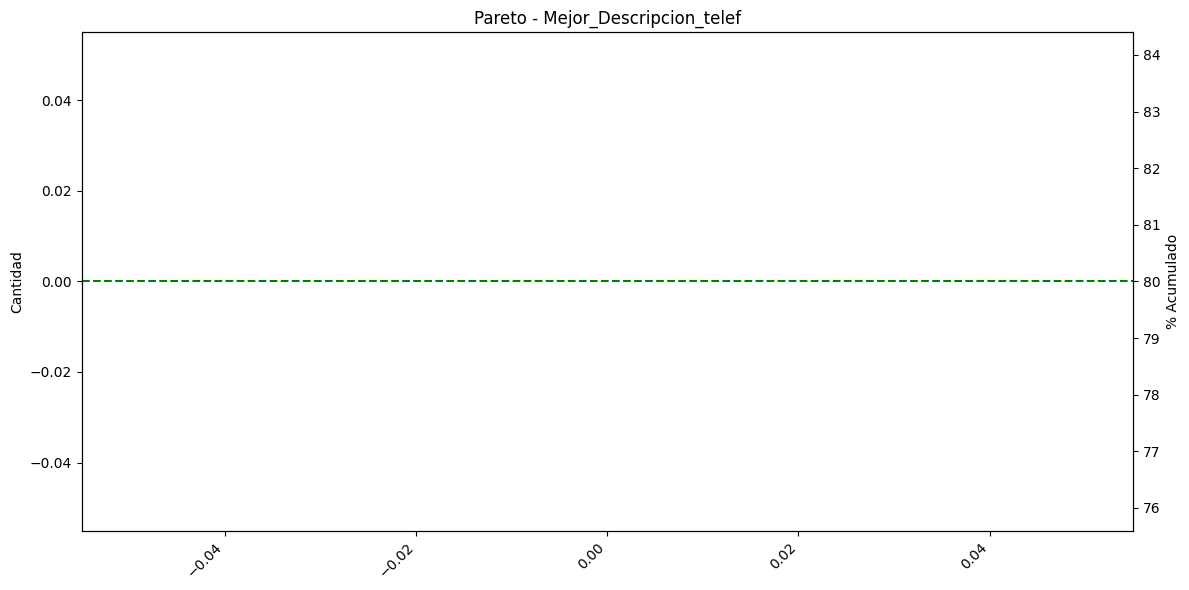

In [129]:

df_dni = df_filtrado.toPandas()
pareto_mejor_descripcion(df_dni,tipificaicon_telf)

In [48]:

exportar_lista(df_filtrado,'tc_cenco_202603301418.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
